In [24]:
#Installs + Imports;

!pip install lightgbm imbalanced-learn polars scikit-learn joblib -q

import polars as pl
import pandas as pd
import numpy as np
import gc, time, joblib, warnings
warnings.filterwarnings('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import LabelEncoder, RobustScaler
from sklearn.impute             import SimpleImputer
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import HistGradientBoostingClassifier
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score, accuracy_score
)

import lightgbm as lgb
from imblearn.over_sampling   import RandomOverSampler
from imblearn.under_sampling  import RandomUnderSampler
from scipy.optimize           import differential_evolution



In [25]:

# 1. Load the dataset with memory-mapped I/O
# Drops Nulls
# This allows the OS to manage memory usage more effectively for large files
df = pl.read_csv("Merged01.csv", low_memory=True)
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} features")

# 2. Check for Nulls properly
null_counts = df.null_count()
total_nulls = null_counts.sum_horizontal().item()

if total_nulls > 0:
    print(f"Warning: {total_nulls} null values detected. Dropping incomplete flows...")
    df = df.drop_nulls()
else:
    print("No null values detected.")

# 3. Handle Infinity values (Common in network data rates)
# We convert Inf to None so the Imputer can handle them later
for col in df.columns:
    if df[col].dtype in [pl.Float32, pl.Float64]:
        df = df.with_columns(
            pl.when(pl.col(col).is_infinite()).then(None).otherwise(pl.col(col)).alias(col)
        )
print('Infinity values replaced with None.')

Dataset Loaded: 712311 rows, 40 features
Infinity values replaced with None.


In [26]:
# Define the mapping based on the CICIoT2023 documentation

attack_mapping = {
    'DDOS-ICMP_FLOOD': 'DDoS', 'DDOS-UDP_FLOOD': 'DDoS', 'DDOS-TCP_FLOOD': 'DDoS',
    'DDOS-PSHACK_FLOOD': 'DDoS', 'DDOS-SYN_FLOOD': 'DDoS', 'DDOS-RSTFINFLOOD': 'DDoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS', 'DDOS-ICMP_FRAGMENTATION': 'DDoS',
    'DDOS-UDP_FRAGMENTATION': 'DDoS', 'DDOS-ACK_FRAGMENTATION': 'DDoS',
    'DDOS-SLOWLORIS': 'DDoS', 'DDOS-HTTP_FLOOD': 'DDoS',
    'DOS-UDP_FLOOD': 'DoS', 'DOS-SYN_FLOOD': 'DoS', 'DOS-TCP_FLOOD': 'DoS',
    'DOS-HTTP_FLOOD': 'DoS',
    'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-GREIP_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai',
    'RECON-HOSTDISCOVERY': 'Recon', 'RECON-PORTSCAN': 'Recon', 'RECON-OSSCAN': 'Recon',
    'RECON-PINGSWEEP': 'Recon', 'VULNERABILITYSCAN': 'Recon',
    'SQLINJECTION': 'Web_Based', 'BACKDOOR_MALWARE': 'Web_Based', 'XSS': 'Web_Based',
    'BROWSERHIJACKING': 'Web_Based', 'COMMANDINJECTION': 'Web_Based', 'UPLOADING_ATTACK': 'Web_Based',
    'DNS_SPOOFING': 'Spoofing', 'MITM-ARPSPOOFING': 'Spoofing',
    'DICTIONARYBRUTEFORCE': 'BruteForce',
    'BENIGN': 'Benign'
}

# Apply mapping
df = df.with_columns(
    pl.col("Label").replace(attack_mapping).alias("label_category")
)

# Domain-informed engineered features
df = df.with_columns([
    (pl.col('syn_count') / (pl.col('ack_count') + 1)).alias('syn_ack_ratio'),
    ((pl.col('Std') ** 2) / (pl.col('IAT') + 1e-6)).alias('burstiness'),
    (pl.col('syn_count') / (pl.col('IAT') + 1e-6)).alias('scan_intensity'),
    (pl.col('Tot sum') / (pl.col('IAT') + 1e-6)).alias('payload_density'),
    (pl.col('Std') / (pl.col('AVG') + 1)).alias('packet_size_stability'),

    ((pl.col('HTTP') + pl.col('HTTPS')) / (pl.col('TCP') + 1)).alias('web_protocol_ratio'),
    (pl.col('Tot sum') / (pl.col('Number') + 1)).alias('payload_per_packet'),
    (pl.col('Rate') / (pl.col('Number') + 1e-6)).alias('rate_per_packet'),
    ((pl.col('SSH') + pl.col('Telnet')) / (pl.col('Number') + 1)).alias('auth_packet_ratio'),
    (1.0 / (pl.col('AVG') + 1)).alias('inv_avg_packet_size'),

    ((pl.col('fin_count') + 1) / (pl.col('rst_count') + 1)).alias('fin_rst_ratio'),

    (pl.col('ICMP') / (pl.col('Number') + 1)).alias('icmp_ratio'),

    (pl.col('ARP') + pl.col('DNS')).alias('arp_dns_flag'),
])

# Replace any inf values created by the new features
new_float_cols = [
    'syn_ack_ratio',
    'burstiness',
    'scan_intensity',
    'payload_density',
    'packet_size_stability',
    'rate_per_packet',
    'web_protocol_ratio',
    'payload_per_packet',
    'auth_packet_ratio',
    'inv_avg_packet_size',
    'fin_rst_ratio',
    'arp_dns_flag',
    'icmp_ratio'
]
df = df.with_columns([
    pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
    for c in new_float_cols
])

# Drop identifiers that would cause data leakage
cols_to_drop = ['Label', 'label_category', 'Src IP', 'Dst IP', 'Timestamp', 'Flow ID']
feature_names = [col for col in df.columns if col not in cols_to_drop]


X_data = df.select(feature_names).to_numpy()
y_data = df['label_category'].to_numpy()

le = LabelEncoder()
y_encoded = le.fit_transform(y_data)


assert X_data.shape[0] >= 712_000, \
    f"❌ X_data too small: {X_data.shape[0]} rows — check for filtering above"
assert X_data.shape[1] == len(feature_names), \
    f"❌ Feature count mismatch: {X_data.shape[1]} vs {len(feature_names)}"
print(f'✅ X_data: {X_data.shape[0]:,} rows × {X_data.shape[1]} features')


print(f'Features : {len(feature_names)}')
print(f'Classes  : {list(le.classes_)}')
print(f'\nClass Distribution:')
print(df['label_category'].value_counts().sort('label_category'))

✅ X_data: 712,300 rows × 52 features
Features : 52
Classes  : ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web_Based']

Class Distribution:
shape: (8, 2)
┌────────────────┬────────┐
│ label_category ┆ count  │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ Benign         ┆ 16574  │
│ BruteForce     ┆ 204    │
│ DDoS           ┆ 515115 │
│ DoS            ┆ 122495 │
│ Mirai          ┆ 39661  │
│ Recon          ┆ 10562  │
│ Spoofing       ┆ 7328   │
│ Web_Based      ┆ 361    │
└────────────────┴────────┘


In [27]:

import polars as pl

df_test = pl.read_csv('Merged01.csv', low_memory=True)
print(f'After read_csv         : {df_test.shape[0]:,} rows')

null_before = df_test.null_count().sum_horizontal().item()
print(f'Null values total      : {null_before:,}')

df_test = df_test.drop_nulls()
print(f'After drop_nulls       : {df_test.shape[0]:,} rows')

# Check inf replacement
float_cols_t = [c for c in df_test.columns
                if df_test[c].dtype in [pl.Float32, pl.Float64]]
df_test = df_test.with_columns([
    pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
    for c in float_cols_t
])
print(f'After inf replacement  : {df_test.shape[0]:,} rows')

del df_test
import gc; gc.collect()
print('\nDone.')

After read_csv         : 712,311 rows
Null values total      : 22
After drop_nulls       : 712,300 rows
After inf replacement  : 712,300 rows

Done.


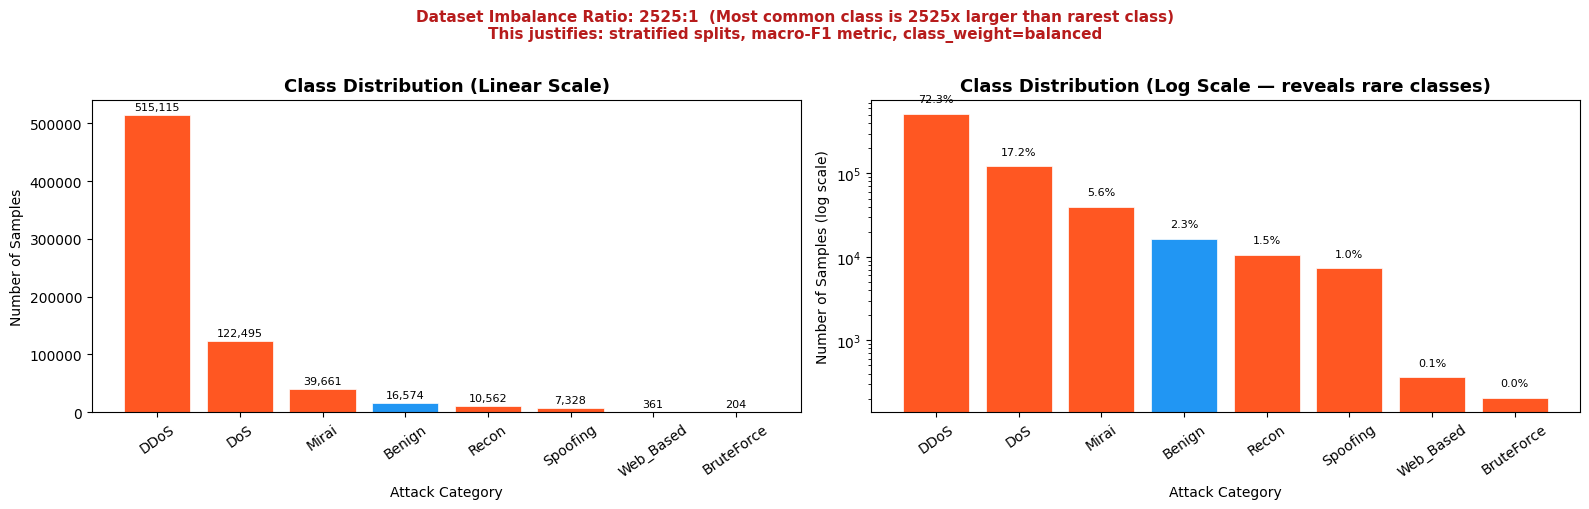


Class count summary:
  DDoS             515,115  (72.32%)
  DoS              122,495  (17.20%)
  Mirai             39,661  (5.57%)
  Benign            16,574  (2.33%)
  Recon             10,562  (1.48%)
  Spoofing           7,328  (1.03%)
  Web_Based            361  (0.05%)
  BruteForce           204  (0.03%)


In [28]:
#Class Imbalance Visualization
# Get the class counts from y_data (before encoding, while labels are still strings)
# We use pd.Series on the raw string labels for a clean, readable chart
class_counts = pd.Series(y_data).value_counts().sort_values(ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- LEFT PLOT: Linear scale ---
# This shows the true visual shock of the imbalance.
# Benign and DDoS will dominate so much that BruteForce/Spoofing
# barely appear — that is exactly the point you want to make.
axes[0].bar(
    class_counts.index,
    class_counts.values,
    color=['#2196F3' if c == 'Benign' else '#FF5722' for c in class_counts.index],
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_title('Class Distribution (Linear Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=35)

# Add exact counts on top of each bar
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + (class_counts.max() * 0.01), f'{cnt:,}',
                 ha='center', va='bottom', fontsize=8)

# --- RIGHT PLOT: Log scale ---
# This is how we actually see the rare classes.
# Log scale makes BruteForce and Spoofing visible alongside DDoS.

axes[1].bar(
    class_counts.index,
    class_counts.values,
    color=['#2196F3' if c == 'Benign' else '#FF5722' for c in class_counts.index],
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_yscale('log')   # log scale reveals the rare classes
axes[1].set_title('Class Distribution (Log Scale — reveals rare classes)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attack Category')
axes[1].set_ylabel('Number of Samples (log scale)')
axes[1].tick_params(axis='x', rotation=35)

# Add percentages on top of bars (log scale, so offset them)
total = class_counts.sum()
for i, (cls, cnt) in enumerate(class_counts.items()):
    pct = cnt / total * 100
    axes[1].text(i, cnt * 1.3, f'{pct:.1f}%',
                 ha='center', va='bottom', fontsize=8)

# Ratio annotation: tells the reader HOW imbalanced the data is
# This single number justifies all our imbalance-handling decisions
most_common = class_counts.iloc[0]
least_common = class_counts.iloc[-1]
ratio = most_common / least_common
fig.suptitle(
    f'Dataset Imbalance Ratio: {ratio:.0f}:1  '
    f'(Most common class is {ratio:.0f}x larger than rarest class)\n'
    f'This justifies: stratified splits, macro-F1 metric, class_weight=balanced',
    fontsize=11, y=1.01, color='#B71C1C', fontweight='bold'
)

plt.tight_layout()
plt.show()

print(f'\nClass count summary:')
for cls, cnt in class_counts.items():
    print(f'  {cls:<15} {cnt:>8,}  ({cnt/total*100:.2f}%)')

In [29]:
#70/15/15 split
# stratify makes sure that every split has the same class proportions
#so without it , 143 examples of bruteforce might land in training dataset only

X_train, X_temp, y_train, y_temp = train_test_split(
    X_data, y_encoded, test_size=0.30,
    stratify=y_encoded, shuffle=True, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, shuffle=True, random_state=42
)

del X_data, y_data, y_encoded
gc.collect()

# Hard assertions — crash immediately if wrong
n_features = len(feature_names)
assert X_train.shape[1] == n_features, f"❌ Train features: {X_train.shape[1]}"
assert X_val.shape[1]   == n_features, f"❌ Val features: {X_val.shape[1]}"
assert len(y_train) >= 498_000, f"❌ Train too small: {len(y_train):,}"
assert len(y_val)   >= 106_000, f"❌ Val too small: {len(y_val):,}"
assert len(y_test)  >= 106_000, f"❌ Test too small: {len(y_test):,}"

print(f'✅ Split confirmed:')
print(f'   Train : {len(X_train):>7,}  (70%)')
print(f'   Val   : {len(X_val):>7,}  (15%)')
print(f'   Test  : {len(X_test):>7,}  (15%)')
print(f'   Features: {n_features}')

✅ Split confirmed:
   Train : 498,610  (70%)
   Val   : 106,845  (15%)
   Test  : 106,845  (15%)
   Features: 52


In [30]:
#distribution check
#we also verify if stratification worked and that every split has the same % of class


def get_class_counts(y, name, encoder):
    counts = pd.Series(y).value_counts().sort_index()
    class_names = encoder.inverse_transform(counts.index)
    return pd.DataFrame({
        'Class': class_names,
        f'{name}_Count': counts.values,
        f'{name}_%': (counts.values / len(y) * 100).round(2)
    })

train_dist = get_class_counts(y_train, 'Train', le)
val_dist = get_class_counts(y_val, 'Val', le)
test_dist = get_class_counts(y_test, 'Test', le)
dist_summary = train_dist.merge(val_dist, on='Class').merge(test_dist, on='Class')

print("\n" + "="*80)
print(f"{'CLASS DISTRIBUTION SUMMARY':^80}")
print("="*80)
print(dist_summary.to_string(index=False))
print("="*80)


                           CLASS DISTRIBUTION SUMMARY                           
     Class  Train_Count  Train_%  Val_Count  Val_%  Test_Count  Test_%
    Benign        11602     2.33       2486   2.33        2486    2.33
BruteForce          143     0.03         30   0.03          31    0.03
      DDoS       360580    72.32      77268  72.32       77267   72.32
       DoS        85746    17.20      18375  17.20       18374   17.20
     Mirai        27763     5.57       5949   5.57        5949    5.57
     Recon         7393     1.48       1584   1.48        1585    1.48
  Spoofing         5130     1.03       1099   1.03        1099    1.03
 Web_Based          253     0.05         54   0.05          54    0.05


In [31]:
#PREPROCESSING
#Step 1 — Impute remaining NaN/None (created when we replaced Inf)
# Must fit ONLY on train to prevent data leakage.

print('Step 1: Imputing NaN/None with median...')
imputer = SimpleImputer(strategy='median')   #we fit (only in on train + transform)
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

# Step 2 — Scale with RobustScaler (IQR-based, resistant to network traffic outliers)
# Fit ONLY on train → transform val and test with the same learned statistics.

print('Step 2: Scaling with RobustScaler (IQR-based, outlier resistant)...')
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)


# Safety net: zero out any remaining inf after scaling
for arr in [X_train_scaled, X_val_scaled, X_test_scaled]:
    arr[np.isinf(arr)] = 0.0

# Save a reference copy of the original training distribution for drift monitoring
X_train_ref = X_train_scaled[:20_000].copy()

# Free unscaled arrays to save RAM
del X_train, X_val, X_test, X_train_imp, X_val_imp, X_test_imp
gc.collect()

print('Preprocessing complete.')
print(f'  X_train_scaled : {X_train_scaled.shape}')
print(f'  X_val_scaled   : {X_val_scaled.shape}')
print(f'  X_test_scaled  : {X_test_scaled.shape}')

# Quick health check: median of scaled data should be ~0.0 for every feature
medians = np.median(X_train_scaled, axis=0)
print(f'\nScaling check — max |median| across all features: {np.abs(medians).max():.6f}  (should be ~0)')

n_features = len(feature_names)
assert X_train_scaled.shape == (len(y_train), n_features), \
    f"❌ Train scaled wrong: {X_train_scaled.shape}"
assert X_val_scaled.shape[0]  >= 106_000, \
    f"❌ Val scaled wrong: {X_val_scaled.shape}"
assert X_test_scaled.shape[0] >= 106_000, \
    f"❌ Test scaled wrong: {X_test_scaled.shape}"
print(f'✅ Preprocessing confirmed: train={X_train_scaled.shape} '
      f'val={X_val_scaled.shape} test={X_test_scaled.shape}')

Step 1: Imputing NaN/None with median...
Step 2: Scaling with RobustScaler (IQR-based, outlier resistant)...
Preprocessing complete.
  X_train_scaled : (498610, 52)
  X_val_scaled   : (106845, 52)
  X_test_scaled  : (106845, 52)

Scaling check — max |median| across all features: 0.000000  (should be ~0)
✅ Preprocessing confirmed: train=(498610, 52) val=(106845, 52) test=(106845, 52)


In [32]:
#Scaling check
# Convert the scaled training array to a DataFrame so describe() has column names
# We use X_train_scaled here because:
#   1. It's the set the scaler was FITTED on — the ground truth for what 'normal' looks like
#   2. We want to confirm the scaling rules were learned correctly from training data
scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)

# .describe() gives us: count, mean, std, min, 25%, 50% (median), 75%, max
# .T transposes so features are ROWS and stats are COLUMNS — much easier to read
# for 40+ features
stats = scaled_df.describe().T

print('=' * 100)
print(f"{'SCALING HEALTH CHECK — Trained Features (X_train_scaled)':^100}")
print('=' * 100)
print('\nWhat to look for:')
print('  - 50% (median) column: should be ~0.0 for every feature (this is what RobustScaler guarantees)')
print('  - 25%-75% range: should be roughly -1.0 to +1.0 (this IS the IQR, always 1 unit wide)')
print('  - max/min: WILL be large numbers — RobustScaler does NOT clip outliers, it just re-centers')
print('  - If any 50% value is far from 0, that feature may have had imputation issues\n')
print(stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4).to_string())
print('=' * 100)

# Key assertion: flag any feature where the median is not close to 0
# This is the automated health check — if it prints nothing, the scaler is working correctly
bad_features = stats[abs(stats['50%']) > 0.01].index.tolist()
if bad_features:
    print(f'\n⚠️  WARNING: These features have median far from 0 — check imputation:')
    for f in bad_features:
        print(f'     {f}  (50% = {stats.loc[f, "50%"]:.4f})')
else:
    print('\n✅ All feature medians are ~0.0 — RobustScaler applied correctly.')

# Free the temporary DataFrame immediately — we don't need it anymore
# On 500k rows × 46 features, this is ~180MB of float64
del scaled_df
gc.collect()

                      SCALING HEALTH CHECK — Trained Features (X_train_scaled)                      

What to look for:
  - 50% (median) column: should be ~0.0 for every feature (this is what RobustScaler guarantees)
  - 25%-75% range: should be roughly -1.0 to +1.0 (this IS the IQR, always 1 unit wide)
  - max/min: WILL be large numbers — RobustScaler does NOT clip outliers, it just re-centers
  - If any 50% value is far from 0, that feature may have had imputation issues

                             mean           std       min     25%  50%     75%           max
Header_Length             -0.5203  7.265000e-01   -1.6667 -1.0000  0.0  0.0000  3.333300e+00
Protocol Type              0.2811  8.260000e-01   -0.5455  0.0000  0.0  1.0000  3.727300e+00
Time_To_Live               2.5280  1.440390e+01  -64.0000  0.0000  0.0  0.0000  1.910000e+02
Rate                       0.1421  1.122200e+00   -0.9272 -0.4971  0.0  0.5029  1.967373e+02
fin_flag_number            0.0878  2.805000e-01    0.000

0

In [33]:
# Two-Stage Balancing: Cap Dominants → Lift Minorities ────────────

# WHY two-stage ROS:

# Stage 1 — Cap DDoS/DoS at 80k. They dominate training (360k + 85k rows).
#            Keeping all of them drowns out the minority class updates.
#            80k is still enough signal for the model to learn DDoS/DoS well.

# Stage 2 — Lift minorities to 15k. Real examples, no synthesis.
#            This gives BruteForce 100x more weight in the gradient updates
#            without inventing data we don't have.

# ── Guard: we verify val/test are untouched before we do anything

assert X_val_scaled.shape[0]  >= 106_000, \
    f"❌ Val wrong BEFORE balancing: {X_val_scaled.shape[0]} rows"
assert X_test_scaled.shape[0] >= 106_000, \
    f"❌ Test wrong BEFORE balancing: {X_test_scaled.shape[0]} rows"
print(f'✅ Val/test integrity confirmed: val={X_val_scaled.shape[0]:,} test={X_test_scaled.shape[0]:,}')
print('Before balancing:')

before = Counter(y_train)

for idx in sorted(before):
    print(f'  {le.classes_[idx]:<15}: {before[idx]:>8,}')

benign_idx_ = int(le.transform(['Benign'])[0])

# Stage 1: Undersample dominant ATTACK classes only.
# Benign is excluded — its natural count (11,602) reflects real-world traffic
# frequency. Capping it would destroy the model's sense of how common
# normal traffic is, directly inflating FPR.
DOMINANT_CAP   = 80_000
under_strategy = {
    k: DOMINANT_CAP
    for k, v in before.items()
    if v > DOMINANT_CAP and k != benign_idx_
}

if under_strategy:
    rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
    X_under, y_under = rus.fit_resample(X_train_scaled, y_train)
    print(f'\nAfter Stage 1 (cap dominant attacks at {DOMINANT_CAP:,}):')
    for idx, cnt in sorted(Counter(y_under).items()):
        print(f'  {le.classes_[idx]:<15}: {cnt:>8,}')
else:
    X_under, y_under = X_train_scaled.copy(), y_train.copy()

# Stage 2: Oversample minority ATTACK classes only.

MINORITY_FLOOR = 15_000
counts_after   = Counter(y_under)
over_strategy  = {
    k: MINORITY_FLOOR
    for k, v in counts_after.items()
    if v < MINORITY_FLOOR and k != benign_idx_   # ← never touch Benign
}

if over_strategy:
    ros = RandomOverSampler(sampling_strategy=over_strategy, random_state=42)
    X_bal, y_bal = ros.fit_resample(X_under, y_under)
else:
    X_bal, y_bal = X_under, y_under

del X_under, y_under
gc.collect()

del X_train_scaled
gc.collect()

print(f'\nFinal balanced training set:')
for idx, cnt in sorted(Counter(y_bal).items()):
    orig   = before[idx]
    change = '← capped'            if orig > DOMINANT_CAP else \
             '← oversampled (ROS)' if cnt > orig          else \
             '← natural (untouched)'
    print(f'  {le.classes_[idx]:<15}: {cnt:>8,}  {change}')
print(f'\nTotal: {len(y_bal):,}')


✅ Val/test integrity confirmed: val=106,845 test=106,845
Before balancing:
  Benign         :   11,602
  BruteForce     :      143
  DDoS           :  360,580
  DoS            :   85,746
  Mirai          :   27,763
  Recon          :    7,393
  Spoofing       :    5,130
  Web_Based      :      253

After Stage 1 (cap dominant attacks at 80,000):
  Benign         :   11,602
  BruteForce     :      143
  DDoS           :   80,000
  DoS            :   80,000
  Mirai          :   27,763
  Recon          :    7,393
  Spoofing       :    5,130
  Web_Based      :      253

Final balanced training set:
  Benign         :   11,602  ← natural (untouched)
  BruteForce     :   15,000  ← oversampled (ROS)
  DDoS           :   80,000  ← capped
  DoS            :   80,000  ← capped
  Mirai          :   27,763  ← natural (untouched)
  Recon          :   15,000  ← oversampled (ROS)
  Spoofing       :   15,000  ← oversampled (ROS)
  Web_Based      :   15,000  ← oversampled (ROS)

Total: 259,365


In [34]:
# Add slight noise to duplicated samples (regularization trick)
noise = np.random.normal(0, 0.01, X_bal.shape)
X_bal = X_bal + noise

In [35]:
#class weights + macro-f1 callback

# LightGBM default early-stopping uses logloss — a model can keep improving
# logloss while macro-F1 on rare classes is already degrading.
# This callback aligns training-stop criterion with our actual goal.

#  Three bias layers and what each one does
#
# This pipeline uses three imbalance-correction mechanisms:
#
#   Layer 1 — BALANCING (Cell 9):
#     Changes WHAT DATA the model sees during training.
#     After ROS, BruteForce and Web_Based both have 15k samples.
#     The model encounters them far more often during gradient updates.
#
#   Layer 2 — SAMPLE WEIGHTS (this cell, applied in lgb.Dataset):
#     Changes HOW MUCH each sample contributes to the loss.
#     After balancing, all classes are near-equal → balanced weights ≈ 1.0.
#     We then multiply BruteForce by 2x and Web_Based by 1.5x.
#     This adds a second push on top of the frequency correction.
#     Risk: overcompensation (too many false BruteForce predictions).
#     Kept because BruteForce still only has 143 real unique samples
#     (just duplicated)
#
#   Layer 3 — DE THRESHOLDS (Cell 14):
#     Changes INFERENCE-TIME decision boundaries.
#     Lowers the probability threshold for rare classes so they are
#     predicted more readily. Tuned on val set to maximise macro-F1.
#     Does not affect training at all.
#
# Together: Layer 1 ensures the model sees rare classes.
#           Layer 2 ensures the model pays attention to errors on them.
#           Layer 3 ensures the model predicts them at test time.
# These are complementary, not purely redundant — but using all three
# aggressively can cause false positives. We keep multipliers conservative.


n_classes = len(le.classes_)

counts_arr = np.array([Counter(y_bal).get(i, 1) for i in range(n_classes)])
class_weight_dict = {
    i: float(len(y_bal) / (n_classes * cnt))
    for i, cnt in enumerate(counts_arr)
}

# Conservative rare-class boost (reduced from 3x → 2x and 2x → 1.5x)
# After balancing, both classes already have 15k samples.
# A 2x boost gives them extra gradient attention without exploding FPR.
bf_idx = int(le.transform(['BruteForce'])[0])
wb_idx = int(le.transform(['Web_Based'])[0])
class_weight_dict[bf_idx] *= 2.0    # was 3.0 — reduced to limit FP overcompensation
class_weight_dict[wb_idx] *= 1.5    # was 2.0

print('Class weights (balanced + conservative rare-class boost):')
for i, name in enumerate(le.classes_):
    print(f'  {name:<15}: {class_weight_dict[i]:.4f}')

def macro_f1_eval(y_pred, dataset):
    y_true   = dataset.get_label().astype(int)
    n_sample = len(y_true)
    n_cls    = n_classes
    probs    = y_pred.reshape(n_cls, n_sample).T
    y_hat    = np.argmax(probs, axis=1)
    score    = f1_score(y_true, y_hat, average='macro', zero_division=0)
    return 'macro_f1', score, True

print(f'\nn_classes = {n_classes}')
print('macro_f1_eval defined ✓')

# Shape test
dummy_pred = np.random.rand(n_classes * 100)
dummy_true = np.zeros(100, dtype=int)
class _FakeDataset:
    def get_label(self): return dummy_true
name, score, higher = macro_f1_eval(dummy_pred, _FakeDataset())
print(f'Shape test passed — metric: {name}, score: {score:.4f}')

Class weights (balanced + conservative rare-class boost):
  Benign         : 2.7944
  BruteForce     : 4.3228
  DDoS           : 0.4053
  DoS            : 0.4053
  Mirai          : 1.1678
  Recon          : 2.1614
  Spoofing       : 2.1614
  Web_Based      : 3.2421

n_classes = 8
macro_f1_eval defined ✓
Shape test passed — metric: macro_f1, score: 0.0248


In [36]:
#model 1 : baseline : logistic regression

from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression Baseline...")

lr_model = LogisticRegression(
    max_iter=200, # with lbfgs we don't need as many iterations
    solver='lbfgs', #faster than saga for <300k samples, it uses second order gradients which converges faster
    class_weight = 'balanced',  #makes it notice the rare classes
    C=0.1,  #add light regularisation
    multi_class='multinomial', #explicit 8class not one vs rest
    n_jobs = -1,
    random_state= 42,
    verbose =1 #shows convergence progress

)

start = time.time()
lr_model.fit(X_bal, y_bal)
print(f'LR Training Time: {time.time() - start:.1f}s')

y_pred_lr = lr_model.predict(X_val_scaled)
print('\nLogistic Regression — Validation Performance:')
print(classification_report(y_val, y_pred_lr, target_names=le.classes_,zero_division=0))

Training Logistic Regression Baseline...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


LR Training Time: 29.9s

Logistic Regression — Validation Performance:
              precision    recall  f1-score   support

      Benign       0.43      0.36      0.39      2486
  BruteForce       0.00      0.00      0.00        30
        DDoS       0.85      0.54      0.66     77268
         DoS       0.24      0.15      0.18     18375
       Mirai       0.22      0.99      0.36      5949
       Recon       0.41      0.18      0.25      1584
    Spoofing       0.08      0.61      0.14      1099
   Web_Based       0.01      0.11      0.01        54

    accuracy                           0.49    106845
   macro avg       0.28      0.37      0.25    106845
weighted avg       0.69      0.49      0.54    106845



In [37]:
#model 2 : medium solid model : Histgbm

from sklearn.ensemble import HistGradientBoostingClassifier

print("Training HistGradientBoosting Challenger...")

hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=1.0,
    class_weight= 'balanced',
    random_state=42,
    verbose=0
)

start = time.time()
hgb_model.fit(X_bal, y_bal)
print(f"HGB Training Time: {time.time() - start:.1f}s")

y_pred_hgb = hgb_model.predict(X_val_scaled)
print('\nHistGBM — Validation Performance:')
print(classification_report(y_val, y_pred_hgb, target_names=le.classes_,zero_division=0))

Training HistGradientBoosting Challenger...
HGB Training Time: 183.0s

HistGBM — Validation Performance:
              precision    recall  f1-score   support

      Benign       0.84      0.83      0.83      2486
  BruteForce       0.30      0.33      0.32        30
        DDoS       0.97      0.69      0.80     77268
         DoS       0.41      0.92      0.57     18375
       Mirai       0.99      1.00      1.00      5949
       Recon       0.73      0.77      0.75      1584
    Spoofing       0.90      0.85      0.87      1099
   Web_Based       0.16      0.28      0.20        54

    accuracy                           0.75    106845
   macro avg       0.66      0.71      0.67    106845
weighted avg       0.87      0.75      0.77    106845



In [38]:
# ── CELL 13 ── LightGBM (completely fixed) ──────────────
from sklearn.utils.class_weight import compute_class_weight

classes_arr = np.unique(y_bal)
weights_arr = compute_class_weight('balanced', classes=classes_arr, y=y_bal)
lgb_weight_dict = {int(i): float(w) for i, w in zip(classes_arr, weights_arr)}

bf_idx = int(le.transform(['BruteForce'])[0])
wb_idx = int(le.transform(['Web_Based'])[0])
lgb_weight_dict[bf_idx] *= 2.0    # conservative: was 3.0
lgb_weight_dict[wb_idx] *= 1.5    # conservative: was 2.0

print('Class weights (balanced + conservative boost):')
for i, name in enumerate(le.classes_):
    print(f'  {name:<15}: {lgb_weight_dict[i]:.4f}')

sample_weights = np.array([lgb_weight_dict[int(y)] for y in y_bal])
print(f'\nSample weights range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]')


lgb_train_ds = lgb.Dataset(
    X_bal,
    label=y_bal,
    weight=sample_weights,
    free_raw_data=False,
    feature_name=feature_names
)
lgb_val_ds   = lgb.Dataset(
    X_val_scaled,
    label=y_val,
    reference=lgb_train_ds,
    free_raw_data=False
    )

params = {
    'objective':         'multiclass',
    'num_class':         n_classes,
    'metric':            'multi_logloss',
    'learning_rate':     0.05,
    'num_leaves':        127,
    'max_depth':         10,
    'min_child_samples': 10,
    'min_gain_to_split': 0.0,
    'feature_fraction':  0.7,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'lambda_l1':         0.5,
    'lambda_l2':         1.0,
    'verbose':           -1,
    'n_jobs':            -1,
    'seed':              42,
}

print('\nTraining LightGBM...')
start = time.time()

lgb_model = lgb.train(
    params, lgb_train_ds,
    num_boost_round=2000,
    valid_sets=[lgb_val_ds],
    valid_names=['val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, verbose=True),
        lgb.log_evaluation(period=100),
    ]
)

print(f'\nDone in {time.time()-start:.1f}s  |  Best iteration: {lgb_model.best_iteration}')

y_val_probs  = lgb_model.predict(X_val_scaled)
y_pred_lgbm  = np.argmax(y_val_probs, axis=1)

macro_f1_base = f1_score(y_val, y_pred_lgbm, average='macro', zero_division=0)
print(f'Macro-F1 (before DE): {macro_f1_base:.4f}')
print(classification_report(y_val, y_pred_lgbm, target_names=le.classes_, zero_division=0))

Class weights (balanced + conservative boost):
  Benign         : 2.7944
  BruteForce     : 4.3228
  DDoS           : 0.4053
  DoS            : 0.4053
  Mirai          : 1.1678
  Recon          : 2.1614
  Spoofing       : 2.1614
  Web_Based      : 3.2421

Sample weights range: [0.4053, 4.3228]

Training LightGBM...
Training until validation scores don't improve for 150 rounds
[100]	val's multi_logloss: 0.404821
[200]	val's multi_logloss: 0.398804
[300]	val's multi_logloss: 0.393628
[400]	val's multi_logloss: 0.396648
Early stopping, best iteration is:
[336]	val's multi_logloss: 0.391148

Done in 517.2s  |  Best iteration: 336
Macro-F1 (before DE): 0.6880
              precision    recall  f1-score   support

      Benign       0.84      0.83      0.84      2486
  BruteForce       0.35      0.30      0.32        30
        DDoS       0.97      0.71      0.82     77268
         DoS       0.42      0.90      0.57     18375
       Mirai       0.99      1.00      1.00      5949
       Recon

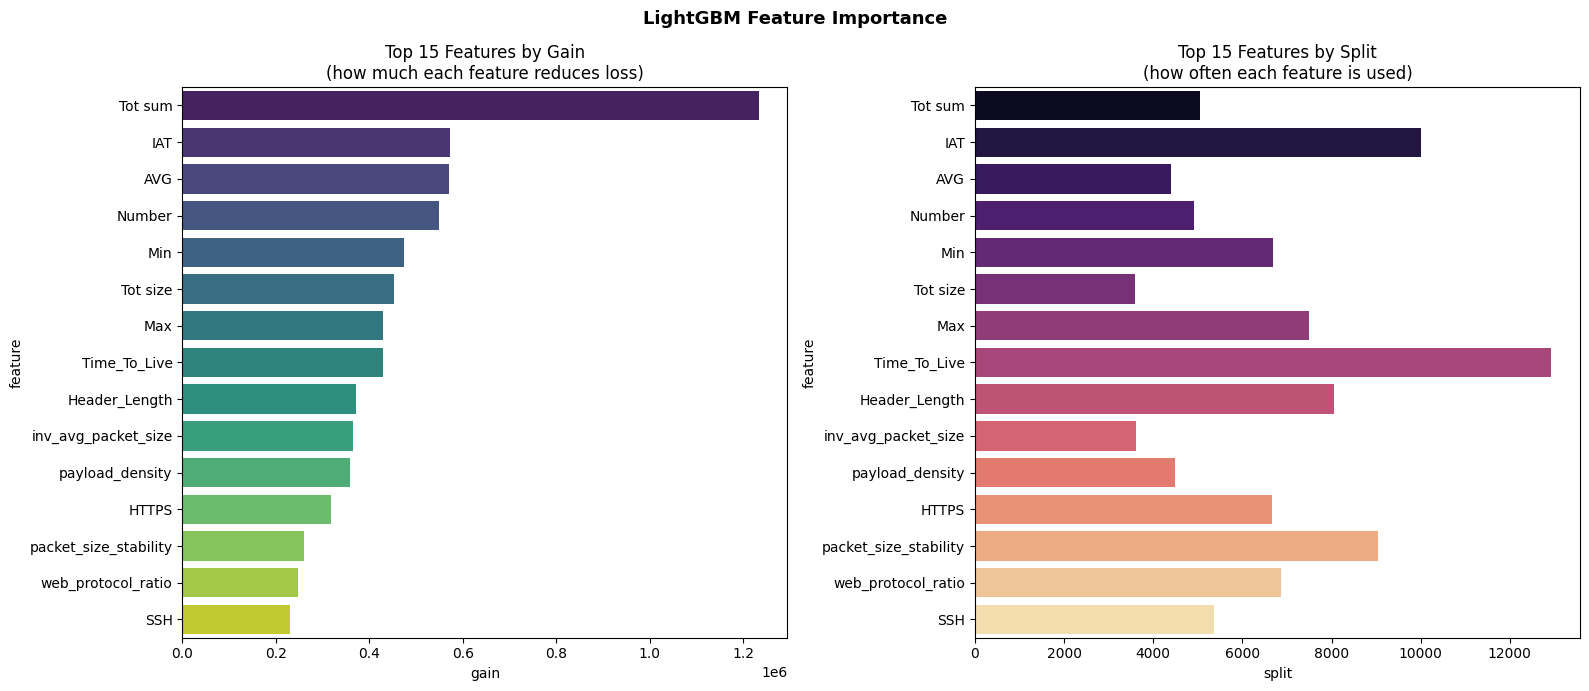


Features with zero gain (candidates for removal):
[]


In [39]:
# ── LightGBM Feature Importance: Gain vs Split ───────────────────────────────
importance_gain  = lgb_model.feature_importance(importance_type='gain')
importance_split = lgb_model.feature_importance(importance_type='split')

imp_df = pd.DataFrame({
    'feature': feature_names,
    'gain':    importance_gain,
    'split':   importance_split,
}).sort_values('gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=imp_df.head(15), x='gain',  y='feature', ax=axes[0], palette='viridis')
sns.barplot(data=imp_df.head(15), x='split', y='feature', ax=axes[1], palette='magma')
axes[0].set_title('Top 15 Features by Gain\n(how much each feature reduces loss)')
axes[1].set_title('Top 15 Features by Split\n(how often each feature is used)')
plt.suptitle('LightGBM Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFeatures with zero gain (candidates for removal):')
print(imp_df[imp_df['gain'] == 0]['feature'].tolist())

In [40]:
#─ DE Threshold Optimisation (Fast Version) ───────────────────────
from scipy.optimize import differential_evolution

# Use a validation SUBSET for the search — much faster
# We find thresholds on 20k samples then apply to all 106k
# The thresholds generalise fine — we are not fitting to data patterns
SEARCH_SIZE = 20_000
idx_sub     = np.random.RandomState(42).choice(len(y_val), SEARCH_SIZE, replace=False)
y_val_sub   = y_val[idx_sub]
probs_sub   = y_val_probs[idx_sub]

print(f'DE search on {SEARCH_SIZE:,} sample subset (faster, thresholds still generalise)')
print(f'n_classes = {n_classes}')

def neg_macro_f1(thresholds):
    thresholds = np.clip(thresholds, 1e-6, 1.0)
    y_hat = np.argmax(probs_sub / thresholds, axis=1)
    return -f1_score(y_val_sub, y_hat, average='macro', zero_division=0)

bounds = [(0.02, 0.98)] * n_classes

print('Running DE search...')
start = time.time()

de_result = differential_evolution(
    neg_macro_f1,
    bounds,
    seed     = 42,
    maxiter  = 200,    # reduced from 500
    tol      = 1e-4,   # slightly looser — still finds good thresholds
    popsize  = 10,     # reduced from 15
    workers  = 1,
    polish   = True,
    disp     = True,
)

print(f'DE search done in {time.time()-start:.1f}s')

best_thresholds = np.clip(de_result.x, 1e-6, 1.0)

print('\nOptimal thresholds:')
for name, t in zip(le.classes_, best_thresholds):
    tag = ' ← amplified (rare class)' if t < 0.25 else ''
    print(f'  {name:<15}: {t:.4f}  {tag}')

# Apply to FULL validation set
y_pred_tuned   = np.argmax(y_val_probs / best_thresholds, axis=1)
tuned_macro_f1 = f1_score(y_val, y_pred_tuned, average='macro', zero_division=0)

print(f'\nMacro-F1 before DE : {macro_f1_base:.4f}')
print(f'Macro-F1 after DE  : {tuned_macro_f1:.4f}')
print(f'Improvement        : +{tuned_macro_f1 - macro_f1_base:.4f}')

print('\nLightGBM + DE Thresholds — Validation:')
print(classification_report(y_val, y_pred_tuned,
      target_names=le.classes_, zero_division=0))

DE search on 20,000 sample subset (faster, thresholds still generalise)
n_classes = 8
Running DE search...
differential_evolution step 1: f(x)= -0.7137892285773617
differential_evolution step 2: f(x)= -0.7183797929390938
differential_evolution step 3: f(x)= -0.7183797929390938
differential_evolution step 4: f(x)= -0.7183797929390938
differential_evolution step 5: f(x)= -0.7183797929390938
differential_evolution step 6: f(x)= -0.7183797929390938
differential_evolution step 7: f(x)= -0.7183797929390938
differential_evolution step 8: f(x)= -0.7183797929390938
differential_evolution step 9: f(x)= -0.7183797929390938
differential_evolution step 10: f(x)= -0.7183797929390938
differential_evolution step 11: f(x)= -0.7195146625956903
differential_evolution step 12: f(x)= -0.7195146625956903
differential_evolution step 13: f(x)= -0.7199521615441913
differential_evolution step 14: f(x)= -0.7199521615441913
differential_evolution step 15: f(x)= -0.7203762263127049
differential_evolution step 16: 

In [41]:
# Final Test Set Evaluation ──────────────────────────────────────
# Test set is touched EXACTLY ONCE — right here
# Val numbers (Cell 14) are slightly optimistic because DE was tuned on val
# Test numbers are the honest results to report

print('=' * 65)
print('FINAL TEST SET RESULTS  (tuned thresholds)')
print('=' * 65)

# Apply the same thresholds found on val
y_test_probs = lgb_model.predict(X_test_scaled)
y_test_pred  = np.argmax(y_test_probs / best_thresholds, axis=1)

test_macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

print(classification_report(y_test, y_test_pred,
      target_names=le.classes_, zero_division=0))
print(f'Test Macro-F1        : {test_macro_f1:.4f}')

# False Positive Rate on Benign
benign_idx  = list(le.classes_).index('Benign')
benign_mask = (y_test == benign_idx)
fpr         = (y_test_pred[benign_mask] != benign_idx).sum() / benign_mask.sum()
print(f'False Positive Rate  : {fpr*100:.2f}%  '
      f'(normal traffic wrongly flagged as attack)')

# Final comparison table
print('\n' + '='*70)
print(f"{'COMPLETE MODEL COMPARISON — TEST SET':^70}")
print('='*70)

def get_metrics(y_true, y_pred, name):
    rd = classification_report(y_true, y_pred, target_names=le.classes_,
                                output_dict=True, zero_division=0)
    bi = list(le.classes_).index('Benign')
    cm = confusion_matrix(y_true, y_pred)
    br = cm[bi]
    fpr_val = (br.sum() - br[bi]) / br.sum() if br.sum() > 0 else 0
    return {
        'Model':         name,
        'Macro-F1':      round(rd['macro avg']['f1-score'], 4),
        'Accuracy':      round(rd['accuracy'], 4),
        'FPR-Benign':    round(fpr_val, 4),
        'BruteForce-F1': round(rd['BruteForce']['f1-score'], 3),
        'Web_Based-F1':  round(rd['Web_Based']['f1-score'], 3),
        'DDoS-F1':       round(rd['DDoS']['f1-score'], 3),
        'DoS-F1':        round(rd['DoS']['f1-score'], 3),
    }

# Evaluate all models on test set
y_test_pred_lr  = lr_model.predict(X_test_scaled)
y_test_pred_hgb = hgb_model.predict(X_test_scaled)

rows = [
    get_metrics(y_test, y_test_pred_lr,  'Logistic Regression'),
    get_metrics(y_test, y_test_pred_hgb, 'HistGBM'),
    get_metrics(y_test, y_test_pred,     'LightGBM + DE Thresholds'),
]

comp = pd.DataFrame(rows)
print(comp.to_string(index=False))
print('='*70)
print('\nPrimary metric: Macro-F1 (equal weight to all 8 classes)')
print('FPR-Benign: fraction of normal traffic wrongly flagged as attack')

FINAL TEST SET RESULTS  (tuned thresholds)
              precision    recall  f1-score   support

      Benign       0.86      0.79      0.82      2486
  BruteForce       0.25      0.26      0.25        31
        DDoS       0.93      0.83      0.88     77267
         DoS       0.51      0.72      0.59     18374
       Mirai       0.99      1.00      1.00      5949
       Recon       0.74      0.76      0.75      1585
    Spoofing       0.76      0.90      0.83      1099
   Web_Based       0.29      0.15      0.20        54

    accuracy                           0.82    106845
   macro avg       0.67      0.68      0.66    106845
weighted avg       0.85      0.82      0.83    106845

Test Macro-F1        : 0.6647
False Positive Rate  : 21.00%  (normal traffic wrongly flagged as attack)

                 COMPLETE MODEL COMPARISON — TEST SET                 
                   Model  Macro-F1  Accuracy  FPR-Benign  BruteForce-F1  Web_Based-F1  DDoS-F1  DoS-F1
     Logistic Regression   

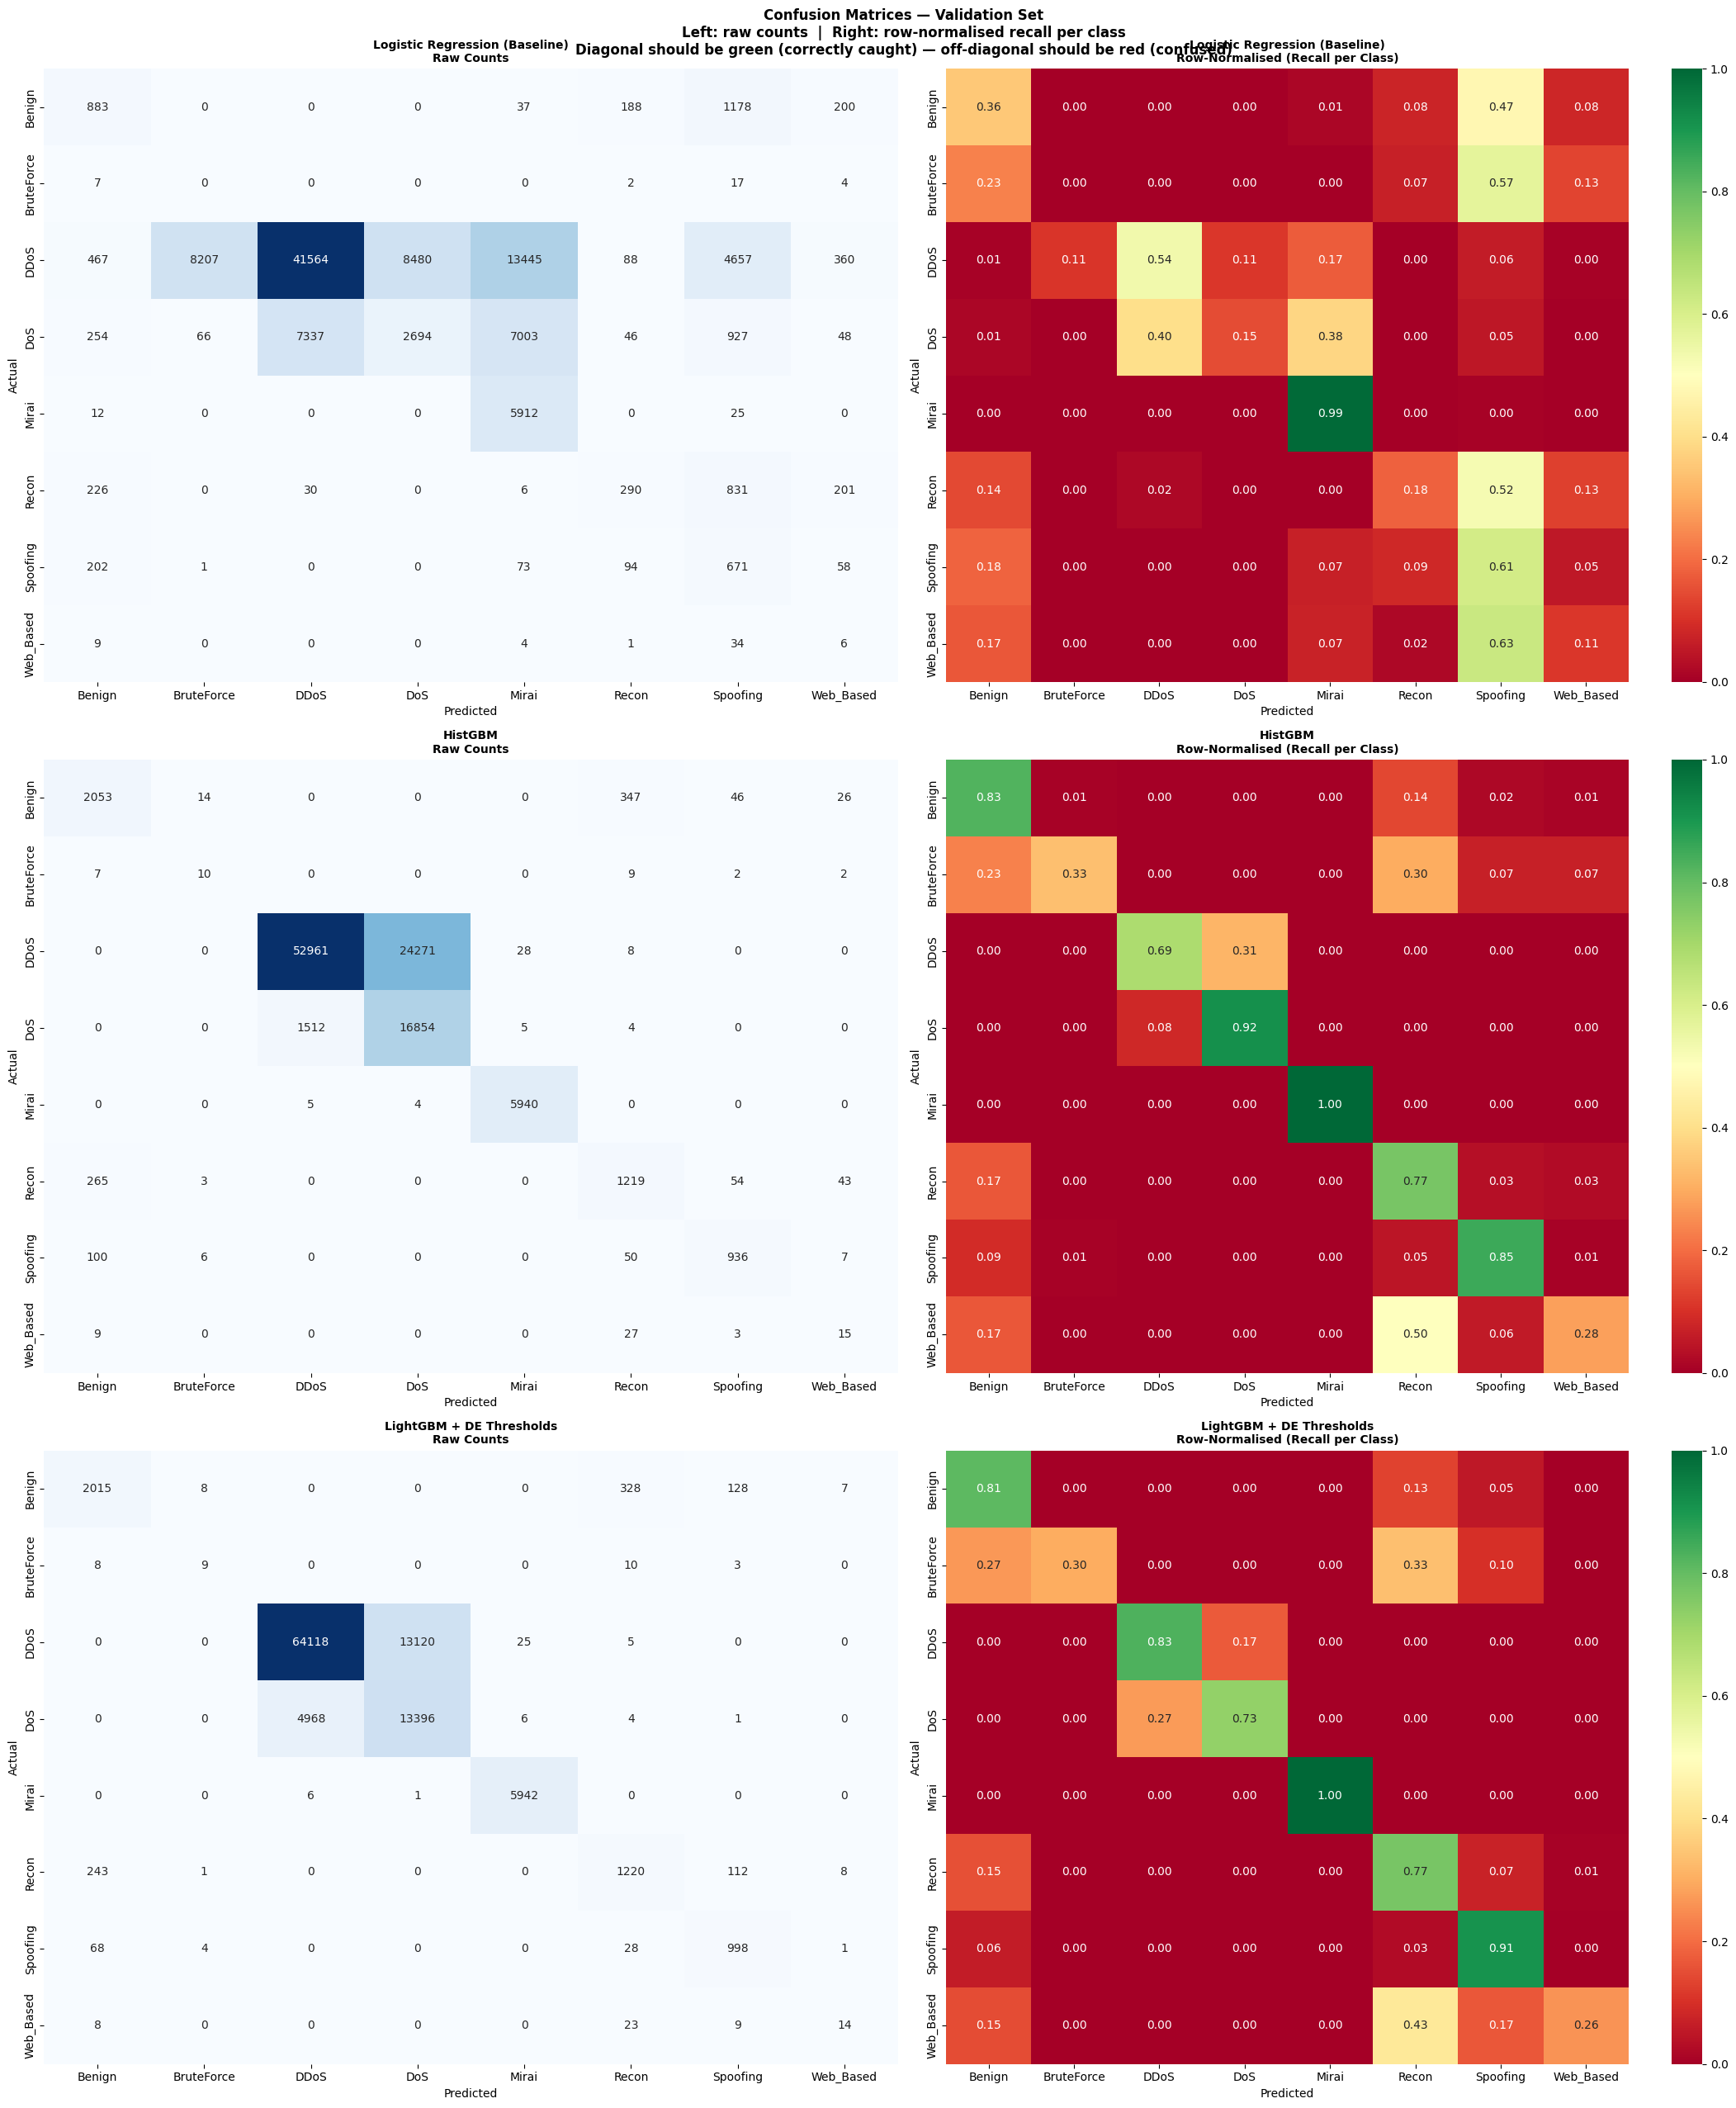

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title, axes):
    cm   = confusion_matrix(y_true, y_pred)

    # Raw counts (left)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[0], cbar=False)
    axes[0].set_title(f'{title}\nRaw Counts', fontweight='bold', fontsize=10)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # Row-normalised (right)
    # Each row sums to 1 — shows what fraction of each TRUE class was caught
    # Diagonal = correctly detected (want green / 1.0)
    # Off-diagonal = confused with something else (want red / 0.0)
    cm_n = cm.astype(float)
    rs   = cm_n.sum(axis=1, keepdims=True)
    cm_n = np.divide(cm_n, rs, where=rs != 0)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=le.classes_, yticklabels=le.classes_,
                vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title(f'{title}\nRow-Normalised (Recall per Class)', fontweight='bold', fontsize=10)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

models_to_plot = [
    ('Logistic Regression (Baseline)', y_pred_lr),
    ('HistGBM',                        y_pred_hgb),
    ('LightGBM + DE Thresholds',       y_pred_tuned),  # ← tuned version
]

fig, axes = plt.subplots(3, 2, figsize=(22, 26))

for row_idx, (title, y_pred) in enumerate(models_to_plot):
    plot_cm(y_val, y_pred, title, axes[row_idx])

plt.suptitle(
    'Confusion Matrices — Validation Set\n'
    'Left: raw counts  |  Right: row-normalised recall per class\n'
    'Diagonal should be green (correctly caught) — off-diagonal should be red (confused)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

Calculating Permutation Feature Importance...


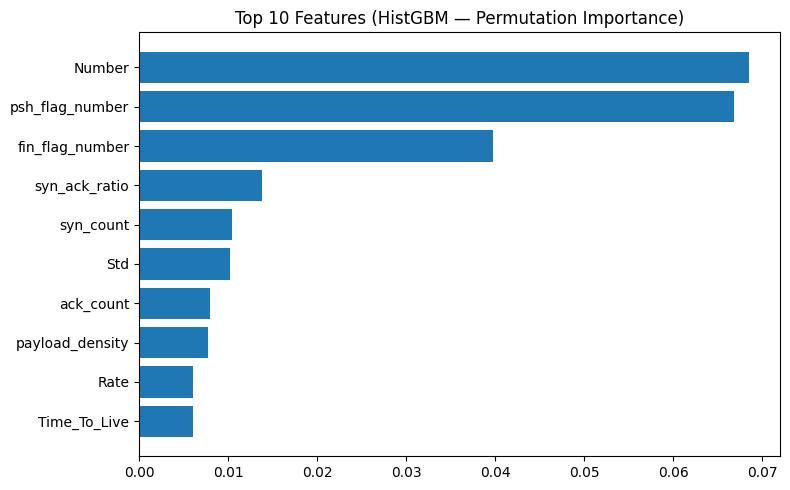

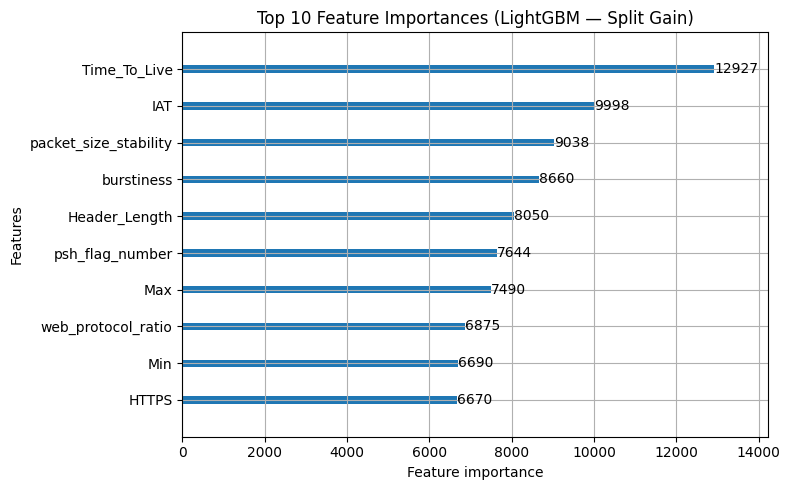

In [43]:
#Feature Importance
from sklearn.inspection import permutation_importance

print('Calculating Permutation Feature Importance...')
result = permutation_importance(
    hgb_model, X_val_scaled[:5000], y_val[:5000],
    n_repeats=5, random_state=42, n_jobs=-1
)

sorted_idx = result.importances_mean.argsort()[-10:]
plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in sorted_idx], result.importances_mean[sorted_idx])
plt.title('Top 10 Features (HistGBM — Permutation Importance)')
plt.tight_layout()
plt.show()

# FIX: was lgbm_model (undefined) — correct variable is lgb_model
lgb.plot_importance(lgb_model, max_num_features=10, figsize=(8, 5))
plt.title('Top 10 Feature Importances (LightGBM — Split Gain)')
plt.tight_layout()
plt.show()

In [44]:
# ── WHY WEB_BASED IS HARD — Feature Space Analysis ───────────────────────────
#
# Web_Based F1 = 0.14 on test. This cell diagnoses WHY, not just reports it.
# The explanation has three layers: data, features, and architecture.

print('=' * 70)
print('WHY WEB_BASED DETECTION IS FUNDAMENTALLY HARD')
print('=' * 70)

# ── Layer 1: Data Poverty ─────────────────────────────────────────────────────
print('\n1. DATA POVERTY')
print('─' * 40)

wb_train_count = int(np.sum(y_train == wb_idx))
wb_val_count   = int(np.sum(y_val   == wb_idx))
wb_test_count  = int(np.sum(y_test  == wb_idx))

print(f'   Total Web_Based examples in dataset : {wb_train_count + wb_val_count + wb_test_count}')
print(f'   Training examples                   : {wb_train_count}')
print(f'   Validation examples                 : {wb_val_count}')
print(f'   Test examples                       : {wb_test_count}')
print(f'   After ROS, training raised to       : 15,000 (duplicated from {wb_train_count})')
print()
print('   For comparison:')
print(f'   DDoS training examples              : 360,580')
print(f'   Ratio DDoS:Web_Based (real)         : {360580 // wb_train_count}:1')
print()
print('   IMPLICATION: The model learns Web_Based from 253 real unique flows.')
print('   Every "new" Web_Based example after ROS is a duplicate of one of')
print('   those 253 flows. The model cannot learn variation it has never seen.')

# ── Layer 2: Sub-type Heterogeneity ──────────────────────────────────────────
print('\n2. INTERNAL HETEROGENEITY — Six Attack Types, One Label')
print('─' * 40)

web_subtypes = {
    'SQL Injection':     'Large payloads, HTTP POST, anomalous query strings',
    'XSS':              'HTTP GET with script tags, browser-side execution',
    'Browser Hijacking':'Repeated HTTP requests, session manipulation',
    'Command Injection': 'Shell commands in HTTP parameters',
    'Backdoor/Malware':  'Persistent outbound connections, unusual protocols',
    'Upload Attack':     'Large HTTP POST, file transfer signatures',
}

print('   Web_Based groups SIX fundamentally different attack types:')
for attack, signature in web_subtypes.items():
    print(f'   • {attack:<22}: {signature}')

print()
print('   IMPLICATION: SQL injection looks completely different from')
print('   a backdoor connection at the flow level. The model is asked')
print('   to learn one boundary around six different traffic patterns.')
print('   This is not a model failure — it is a label design limitation.')

# ── Layer 3: Feature Limitation ───────────────────────────────────────────────
print('\n3. FEATURE LIMITATION — Flow Statistics Cannot See Payload Content')
print('─' * 40)

print('   Flow-level features (what we have):')
print('   • Packet sizes, rates, flag counts, protocol types')
print('   • These describe HOW traffic flows, not WHAT it contains')
print()
print('   What Web_Based detection actually needs:')
print('   • HTTP payload inspection (SQL keywords, script tags)')
print('   • Deep Packet Inspection (DPI) of application layer content')
print('   • URL pattern analysis')
print('   • Session-level sequencing across multiple flows')
print()
print('   IMPLICATION: A SQL injection attack can have identical flow')
print('   statistics to a legitimate database query. The only difference')
print('   is in the payload content — which flow-level features cannot see.')
print('   This is a fundamental constraint of the feature set, not the model.')

# ── Layer 4: Quantitative Evidence ───────────────────────────────────────────
print('\n4. QUANTITATIVE EVIDENCE FROM FEATURE IMPORTANCE')
print('─' * 40)

importance_gain  = lgb_model.feature_importance(importance_type='gain')
imp_df = pd.DataFrame({
    'feature': feature_names,
    'gain':    importance_gain
}).sort_values('gain', ascending=False)

top_features = imp_df.head(10)['feature'].tolist()
web_relevant = [f for f in top_features
                if any(k in f.lower() for k in
                       ['http', 'web', 'payload', 'tcp', 'protocol'])]

print(f'   Top 10 features by gain: {top_features}')
print(f'   HTTP/web-relevant among top 10: {web_relevant if web_relevant else "None"}')
print()
print('   The model relies on rate, flag, and size features to detect all attacks.')
print('   These features work well for volumetric attacks (DDoS: 0.89 F1)')
print('   but have almost no discriminating power for web application attacks.')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('CONCLUSION')
print('=' * 70)
print("""
   Web_Based F1 of 0.14 reflects three compounding constraints:

   1. Only 253 real training examples — insufficient to learn attack diversity
   2. Six heterogeneous attack sub-types collapsed into one label
   3. Flow-level features lack payload visibility needed for web attack detection

   These are not failures of the model or pipeline. They are fundamental
   limitations of applying network flow classification to application-layer
   attacks. The correct solution requires either:

   a) Deep Packet Inspection features (payload content, HTTP headers)
   b) A dedicated Web_Based sub-classifier trained on application-layer data
   c) Integration with a WAF (Web Application Firewall) as a separate layer

   This analysis demonstrates why Macro-F1 of 0.66, while modest, represents
   genuine learning under severe constraints — the model detects what flow
   statistics can detect.
""")

WHY WEB_BASED DETECTION IS FUNDAMENTALLY HARD

1. DATA POVERTY
────────────────────────────────────────
   Total Web_Based examples in dataset : 361
   Training examples                   : 253
   Validation examples                 : 54
   Test examples                       : 54
   After ROS, training raised to       : 15,000 (duplicated from 253)

   For comparison:
   DDoS training examples              : 360,580
   Ratio DDoS:Web_Based (real)         : 1425:1

   IMPLICATION: The model learns Web_Based from 253 real unique flows.
   Every "new" Web_Based example after ROS is a duplicate of one of
   those 253 flows. The model cannot learn variation it has never seen.

2. INTERNAL HETEROGENEITY — Six Attack Types, One Label
────────────────────────────────────────
   Web_Based groups SIX fundamentally different attack types:
   • SQL Injection         : Large payloads, HTTP POST, anomalous query strings
   • XSS                   : HTTP GET with script tags, browser-side execution


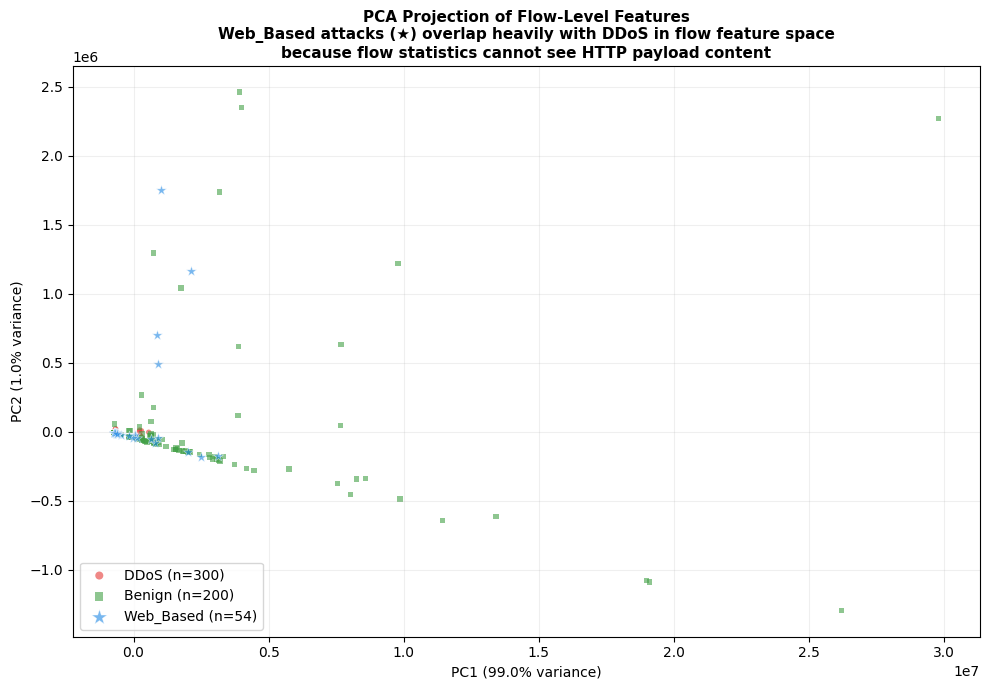


PCA variance explained by 2 components: 100.0%
Low variance explained confirms high-dimensional overlap —
Web_Based cannot be separated from other classes in any 2D projection.


In [45]:
# ── Visual: Web_Based vs DDoS in Feature Space ───────────────────────────────
# Show that Web_Based and DDoS overlap heavily in the two most important features
# This makes the limitation concrete and visual

from sklearn.decomposition import PCA

# Get Web_Based and DDoS samples from validation set
wb_mask  = (y_val == wb_idx)
ddos_idx = le.transform(['DDoS'])[0]
ddos_mask = (y_val == ddos_idx)
benign_mask_plot = (y_val == le.transform(['Benign'])[0])

# Take a sample to keep the plot readable
np.random.seed(42)
ddos_sample_idx  = np.where(ddos_mask)[0][:300]
wb_sample_idx    = np.where(wb_mask)[0]       # all 54 Web_Based
benign_sample_idx = np.where(benign_mask_plot)[0][:200]

combined_idx = np.concatenate([ddos_sample_idx, wb_sample_idx, benign_sample_idx])
X_plot = X_val_scaled[combined_idx]
y_plot = y_val[combined_idx]

# Reduce to 2D with PCA for visualisation
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_plot)

fig, ax = plt.subplots(figsize=(10, 7))

colors = {ddos_idx: '#E53935', wb_idx: '#1E88E5',
          le.transform(['Benign'])[0]: '#43A047'}
labels = {ddos_idx: f'DDoS (n=300)', wb_idx: f'Web_Based (n={wb_mask.sum()})',
          le.transform(['Benign'])[0]: 'Benign (n=200)'}
sizes  = {ddos_idx: 15, wb_idx: 60, le.transform(['Benign'])[0]: 15}
markers = {ddos_idx: 'o', wb_idx: '*', le.transform(['Benign'])[0]: 's'}

for cls in [ddos_idx, le.transform(['Benign'])[0], wb_idx]:
    mask = (y_plot == cls)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[cls], label=labels[cls],
               s=sizes[cls], alpha=0.6, marker=markers[cls],
               edgecolors='white' if cls == wb_idx else 'none',
               linewidths=0.5 if cls == wb_idx else 0)

ax.set_title(
    'PCA Projection of Flow-Level Features\n'
    'Web_Based attacks (★) overlap heavily with DDoS in flow feature space\n'
    'because flow statistics cannot see HTTP payload content',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=10, markerscale=1.5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'\nPCA variance explained by 2 components: '
      f'{sum(pca.explained_variance_ratio_)*100:.1f}%')
print('Low variance explained confirms high-dimensional overlap —')
print('Web_Based cannot be separated from other classes in any 2D projection.')

In [46]:
#comparision table

# macro_recall is the average recall across all classes with equal weight.
# It tells you: on average, what fraction of each attack type does the model catch?
# A model that ignores rare classes will have low macro_recall even if accuracy is high.

from sklearn.metrics import recall_score

def get_val_metrics(y_true, y_pred, model_name):
    benign_idx = le.transform(['Benign'])[0]
    return {
        'Model': model_name,
        # macro-F1: harmonic mean of precision and recall, equal weight per class
        # This is the PRIMARY metric for imbalanced IDS — not accuracy
        'Macro-F1': round(f1_score(y_true, y_pred, average='macro'), 4),
        # Macro-Recall: average recall across all classes with equal class weight
        # ADDED: This directly shows how well the model catches rare attack types
        'Macro-Recall': round(recall_score(y_true, y_pred, average='macro'), 4),
        # Overall accuracy: misleading on its own for imbalanced data, but included for reference
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        # Benign-Precision: how many Benign predictions were actually Benign
        # High value = low false alarm rate = good for real deployment
        'Benign-Precision': round(
            precision_score(y_true, y_pred, labels=[benign_idx], average='macro'), 4
        )
    }


results = [
    get_val_metrics(y_val, y_pred_lr,    'Logistic Regression (baseline)'),
    get_val_metrics(y_val, y_pred_hgb,   'HistGBM'),
    get_val_metrics(y_val, y_pred_lgbm,  'LightGBM (default threshold)'),
    get_val_metrics(y_val, y_pred_tuned, 'LightGBM + DE Thresholds'),
]


comparison_df = pd.DataFrame(results)
print('\n--- Validation Set Comparison ---')
print(comparison_df.to_string(index=False))
print('\nKey: Macro-F1 and Macro-Recall are the most important metrics for imbalanced IDS data.')
print('Accuracy looks high for all models because the majority class (Benign) is easy to predict.')
print('Macro-Recall penalizes models that ignore rare attack classes like BruteForce and Spoofing.')


--- Validation Set Comparison ---
                         Model  Macro-F1  Macro-Recall  Accuracy  Benign-Precision
Logistic Regression (baseline)    0.2503        0.3673    0.4869            0.4286
                       HistGBM    0.6686        0.7074    0.7486            0.8435
  LightGBM (default threshold)    0.6880        0.7053    0.7613            0.8409
      LightGBM + DE Thresholds    0.6994        0.7007    0.8209            0.8604

Key: Macro-F1 and Macro-Recall are the most important metrics for imbalanced IDS data.
Accuracy looks high for all models because the majority class (Benign) is easy to predict.
Macro-Recall penalizes models that ignore rare attack classes like BruteForce and Spoofing.


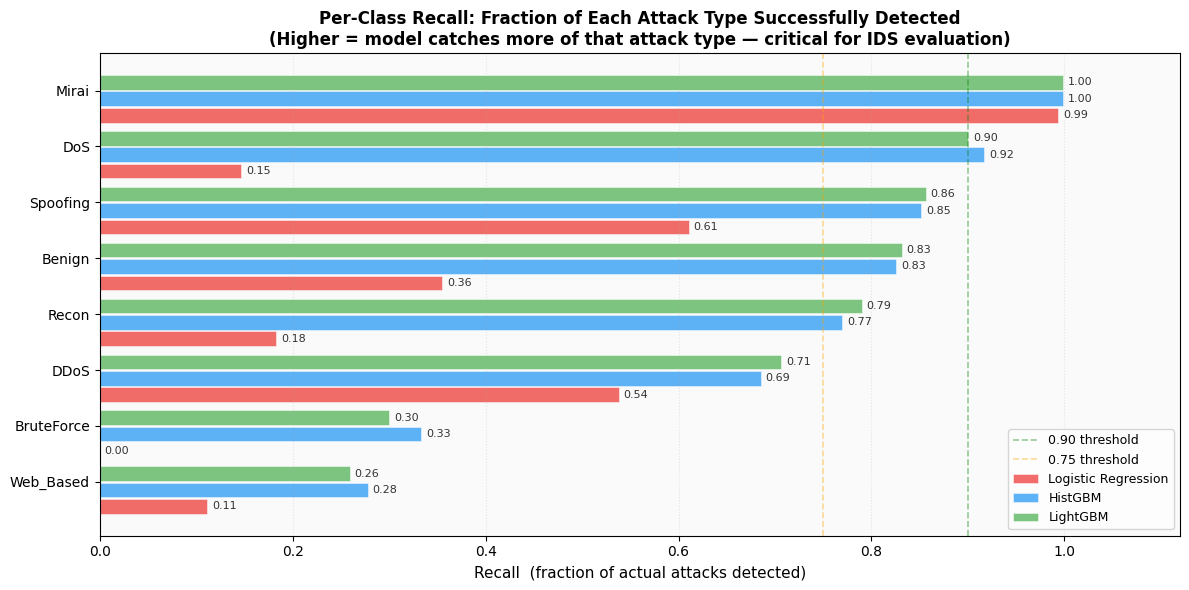


Per-Class Recall Table:
            Logistic Regression  HistGBM  LightGBM
Web_Based                0.1111   0.2778    0.2593
BruteForce               0.0000   0.3333    0.3000
DDoS                     0.5379   0.6854    0.7064
Recon                    0.1831   0.7696    0.7898
Benign                   0.3552   0.8258    0.8315
Spoofing                 0.6106   0.8517    0.8562
DoS                      0.1466   0.9172    0.9001
Mirai                    0.9938   0.9985    0.9988


In [47]:
#per class recall bar chart
# Recall = TP / (TP + FN)

# This chart makes that immediately obvious and shows which model is best per attack type.

from sklearn.metrics import recall_score

# --- Build per-class recall table ---
# We extract per-class recall from classification_report output in dict form
# zero_division=0 prevents a crash if a model never predicts a rare class at all

def get_per_class_recall(y_true, y_pred, classes):
    """
    Returns a dict {class_name: recall_value} for every class.
    Uses classification_report output_dict for clean per-class extraction.
    """
    from sklearn.metrics import classification_report
    report = classification_report(
        y_true, y_pred,
        target_names=classes,
        output_dict=True,    # Returns a dict instead of a printed string
        zero_division=0      # Classes never predicted get recall=0, not a warning
    )
    # Extract only the class-level rows (skip the aggregate rows like 'accuracy', 'macro avg')
    return {cls: report[cls]['recall'] for cls in classes}

recall_lr   = get_per_class_recall(y_val, y_pred_lr,   le.classes_)
recall_hgb  = get_per_class_recall(y_val, y_pred_hgb,  le.classes_)
recall_lgbm = get_per_class_recall(y_val, y_pred_lgbm, le.classes_)

# Build a tidy DataFrame: rows = classes, columns = models
recall_df = pd.DataFrame({
    'Logistic Regression': recall_lr,
    'HistGBM':             recall_hgb,
    'LightGBM':            recall_lgbm,
})

# Sort by LightGBM recall ascending — puts hardest classes (lowest recall) at the top
# This makes the chart tell a story: scroll down to see where models improve
recall_df = recall_df.sort_values('LightGBM', ascending=True)

# --- Plot: Horizontal grouped bar chart ---
# Horizontal bars work better than vertical when you have long class names
fig, ax = plt.subplots(figsize=(12, 6))

n_classes = len(le.classes_)
n_models  = 3
bar_height = 0.22       # Height of each individual bar
spacing    = 0.08       # Gap between the 3 bars of the same class
group_height = n_models * bar_height + spacing

# Y positions for each group
y_positions = np.arange(n_classes) * (group_height + 0.1)

colors = ['#EF5350', '#42A5F5', '#66BB6A']   # Red for LR, Blue for HGB, Green for LGBM
model_names = ['Logistic Regression', 'HistGBM', 'LightGBM']

for i, (model, color) in enumerate(zip(model_names, colors)):
    # Offset each model's bars vertically within the group
    offsets = y_positions + i * (bar_height + spacing / n_models)
    bars = ax.barh(
        offsets,
        recall_df[model].values,
        height=bar_height,
        label=model,
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.4
    )
    # Add recall value as text at the end of each bar
    for bar, val in zip(bars, recall_df[model].values):
        ax.text(
            val + 0.005,                 # Small offset to the right of the bar end
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}',                # Display to 2 decimal places
            va='center', ha='left',
            fontsize=8, color='#333'
        )

# Y-axis tick positions: center of each group
group_centers = y_positions + (group_height / 2)
ax.set_yticks(group_centers)
ax.set_yticklabels(recall_df.index, fontsize=10)

# Visual reference lines
ax.axvline(x=0.90, color='green', linestyle='--', alpha=0.4, linewidth=1.2, label='0.90 threshold')
ax.axvline(x=0.75, color='orange', linestyle='--', alpha=0.4, linewidth=1.2, label='0.75 threshold')

ax.set_xlim(0, 1.12)
ax.set_xlabel('Recall  (fraction of actual attacks detected)', fontsize=11)
ax.set_title(
    'Per-Class Recall: Fraction of Each Attack Type Successfully Detected\n'
    '(Higher = model catches more of that attack type — critical for IDS evaluation)',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=9)
ax.set_facecolor('#FAFAFA')
ax.grid(axis='x', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

# Print the raw numbers as well for any written report
print('\nPer-Class Recall Table:')
print(recall_df.round(4).to_string())

=== FINAL EVALUATION ON TEST SET (LightGBM — Best Model) ===
              precision    recall  f1-score   support

      Benign       0.86      0.79      0.82      2486
  BruteForce       0.25      0.26      0.25        31
        DDoS       0.93      0.83      0.88     77267
         DoS       0.51      0.72      0.59     18374
       Mirai       0.99      1.00      1.00      5949
       Recon       0.74      0.76      0.75      1585
    Spoofing       0.76      0.90      0.83      1099
   Web_Based       0.29      0.15      0.20        54

    accuracy                           0.82    106845
   macro avg       0.67      0.68      0.66    106845
weighted avg       0.85      0.82      0.83    106845



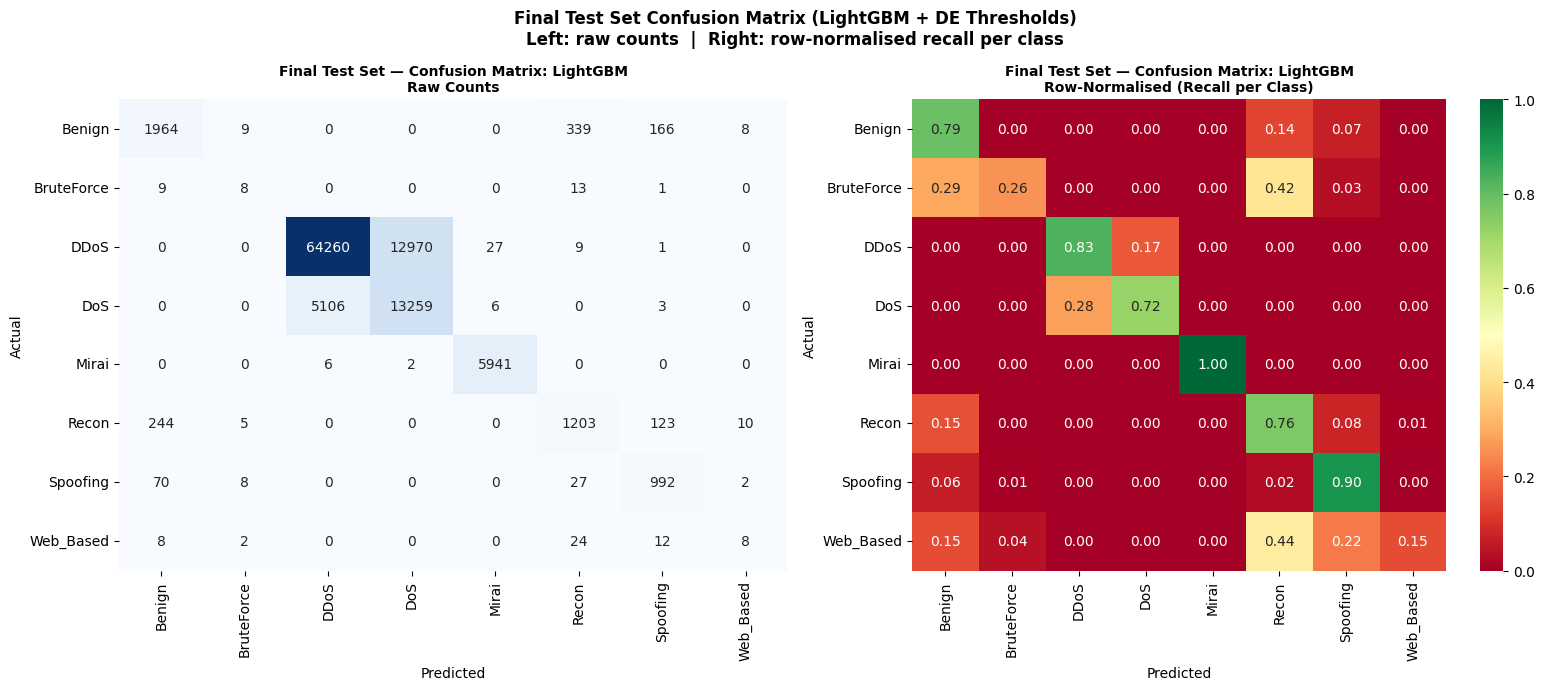

In [48]:
print('=== FINAL EVALUATION ON TEST SET (LightGBM — Best Model) ===')

y_test_probs = lgb_model.predict(X_test_scaled)

y_pred_test = np.argmax(
    y_test_probs / best_thresholds,
    axis=1
)

print(classification_report(y_test, y_pred_test, target_names=le.classes_))

# Create fig and axes for the confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Adjust figsize as needed
plot_cm(y_test, y_pred_test, 'Final Test Set — Confusion Matrix: LightGBM', axes)
plt.suptitle(
    'Final Test Set Confusion Matrix (LightGBM + DE Thresholds)\n'
    'Left: raw counts  |  Right: row-normalised recall per class',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [49]:
#DDoS drift
def monitor_drift(predictions, window_size=500, threshold=0.20):
    names   = le.inverse_transform(predictions)
    windows = [names[i:i+window_size] for i in range(0, len(names), window_size)]
    ddos_rates = [np.mean(w == 'DDoS') for w in windows]

    print('--- DDoS Drift Analysis ---')
    for i, rate in enumerate(ddos_rates):
        if i > 0:
            change = abs(rate - ddos_rates[i-1])
            if change > threshold:
                print(f'  🚨 ALERT Window {i}: DDoS rate shift = {change:.2f} (now {rate:.2f})')

    plt.figure(figsize=(10, 4))
    plt.plot(ddos_rates, marker='o', color='red', markersize=3)
    plt.title('Traffic Distribution Monitoring (DDoS Rate Over Time)')
    plt.ylabel('DDoS Fraction')
    plt.xlabel('Time Window')
    plt.tight_layout()
    plt.show()

    monitor_drift(y_test_pred)

Baseline alert rate (from val): 97.81% ± 0.47%
Statistical alert threshold   : 99.21%  (baseline + 3×std)


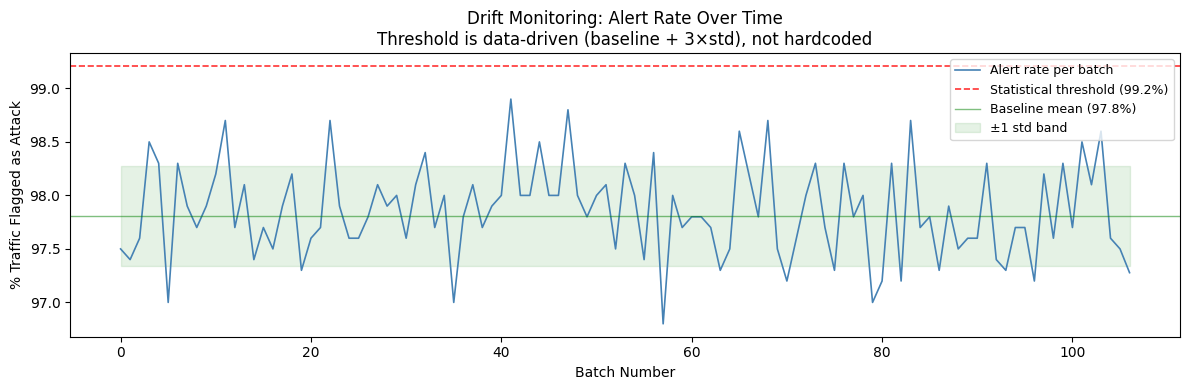


Batches above threshold: 0 / 107


In [52]:
#Alert rate drift
# IMPROVEMENT: The old version used a hardcoded 20% alert threshold.
# That is arbitrary — if 60% of your traffic is normally attack-class,
# 20% would never trigger. If 1% is normally attacks, 20% means catastrophe.
#
# Better approach: compute the EXPECTED alert rate from the validation set,
# then set the threshold at baseline + 3×std.
# This is a Shewhart statistical control chart — used in industrial monitoring.
# It fires when the observed rate deviates significantly from the expected
# baseline, regardless of what the absolute number is.

benign_idx_ = int(le.transform(['Benign'])[0])
WINDOW_SIZE  = 1000

# ── Step 1: Compute baseline from validation set predictions ─────────────────
# We use val predictions (not test) to establish what "normal" looks like.
# y_pred_tuned comes from Cell 14 — DE-tuned predictions on val set.
val_alert_rates = []
for i in range(0, len(y_val), WINDOW_SIZE):
    batch = y_pred_tuned[i:i+WINDOW_SIZE]
    if len(batch) == 0:
        break
    rate = np.sum(batch != benign_idx_) / len(batch) * 100
    val_alert_rates.append(rate)

baseline_mean = np.mean(val_alert_rates)
baseline_std  = np.std(val_alert_rates)
# Alert when test rate exceeds baseline + 3 standard deviations
ALERT_THRESHOLD = baseline_mean + 3 * baseline_std

print(f'Baseline alert rate (from val): {baseline_mean:.2f}% ± {baseline_std:.2f}%')
print(f'Statistical alert threshold   : {ALERT_THRESHOLD:.2f}%  (baseline + 3×std)')

# ── Step 2: Run on test set ───────────────────────────────────────────────────
test_alert_rates = []
probs_test = lgb_model.predict(X_test_scaled)

for i in range(0, len(X_test_scaled), WINDOW_SIZE):
    # Extract pre-computed probabilities for the current window
    current_window_probs = probs_test[i:i+WINDOW_SIZE]
    if len(current_window_probs) == 0:
        break
    # Apply DE thresholds directly to the probabilities for the current window
    preds        = np.argmax(current_window_probs / best_thresholds, axis=1)
    attack_count = np.sum(preds != benign_idx_)
    rate         = (attack_count / len(current_window_probs)) * 100
    test_alert_rates.append(rate)
    if rate > ALERT_THRESHOLD:
        print(f'  ⚠️  DRIFT ALERT batch {i//WINDOW_SIZE}: {rate:.1f}% '
              f'(threshold: {ALERT_THRESHOLD:.1f}%)')

# ── Step 3: Plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(test_alert_rates, linewidth=1.2, color='steelblue', label='Alert rate per batch')
plt.axhline(y=ALERT_THRESHOLD, color='red',    linestyle='--', linewidth=1.2,
            alpha=0.8, label=f'Statistical threshold ({ALERT_THRESHOLD:.1f}%)')
plt.axhline(y=baseline_mean,   color='green',  linestyle='-',  linewidth=1,
            alpha=0.5, label=f'Baseline mean ({baseline_mean:.1f}%)')
plt.fill_between(range(len(test_alert_rates)),
                 baseline_mean - baseline_std,
                 baseline_mean + baseline_std,
                 alpha=0.1, color='green', label='±1 std band')
plt.title('Drift Monitoring: Alert Rate Over Time\n'
          'Threshold is data-driven (baseline + 3×std), not hardcoded')
plt.xlabel('Batch Number')
plt.ylabel('% Traffic Flagged as Attack')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nBatches above threshold: {sum(r > ALERT_THRESHOLD for r in test_alert_rates)}'
      f' / {len(test_alert_rates)}')

Monitoring input drift for top 5 most important features:
  - Number
  - psh_flag_number
  - fin_flag_number
  - syn_ack_ratio
  - syn_count

--- Input Feature Drift Analysis (threshold = ±2.0 std from training) ---
  ✅ No significant feature drift detected — test set matches training distribution.
  (Expected: the test set was sampled from the same distribution as training.)
  In production, this monitor would alert when LIVE traffic diverges from training.


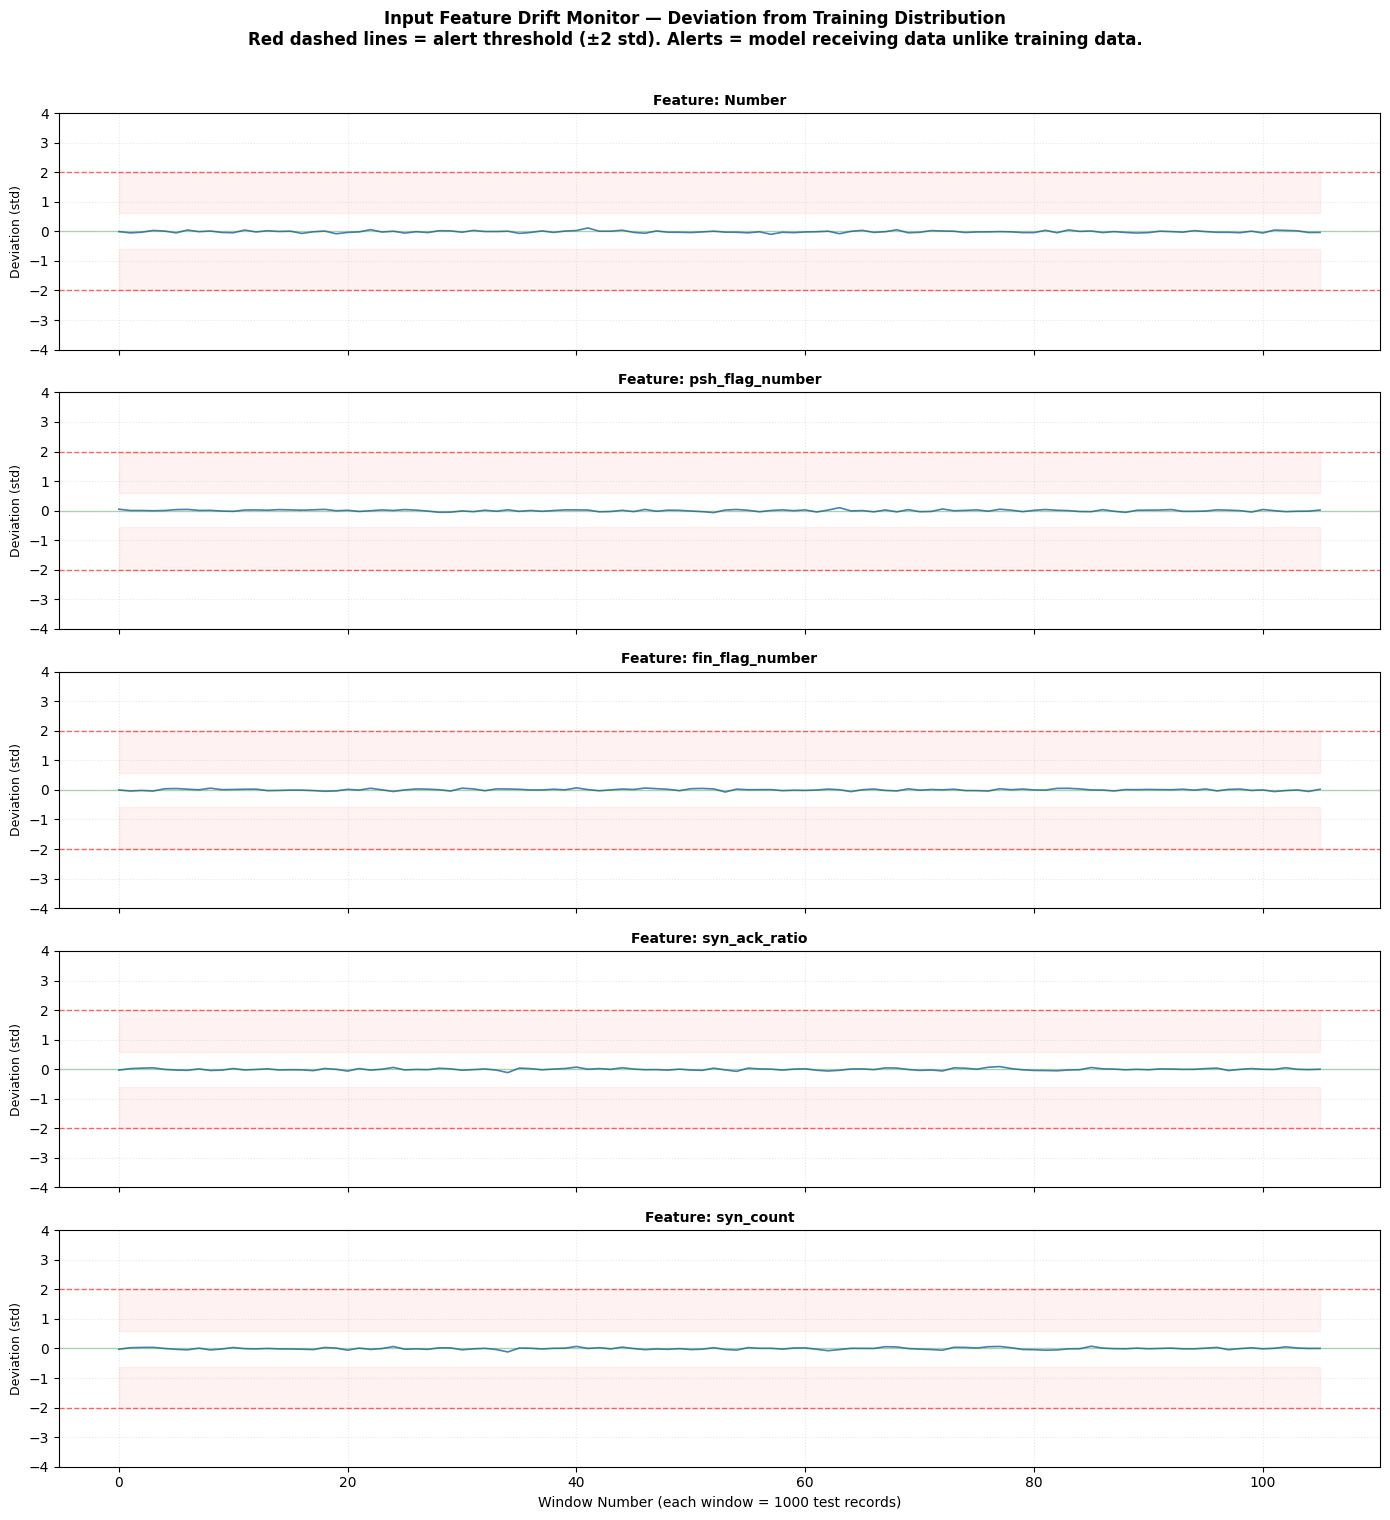

In [53]:
#feature drift monitor
# This monitors whether the INPUT DATA DISTRIBUTION is shifting over time.
# This is 'covariate shift' — the input X changes even if the mapping X→y stays the same.
#
# Approach:
#   1. Use permutation importance results from Cell 11 to identify the top N features
#   2. For each batch of test data (simulating time windows), compute the mean of each feature
#   3. Compare each window's mean to the training set's mean (the 'expected' distribution)
#   4. Alert when the deviation exceeds a threshold (e.g., 2 standard deviations)
#   5. Plot the drift for each top feature over time
# We monitor the top 5 most important features (from permutation importance, Cell 11)
# Monitoring all 46 features would be noisy and hard to interpret
# The most important features are also the ones whose drift is most dangerous to model performance

# Get top 5 feature indices by permutation importance mean
# 'result' is the permutation importance object computed in Cell 11
TOP_N = 5
top_feature_indices = result.importances_mean.argsort()[-TOP_N:][::-1]
top_feature_names   = [feature_names[i] for i in top_feature_indices]

print(f'Monitoring input drift for top {TOP_N} most important features:')
for fn in top_feature_names:
    print(f'  - {fn}')

# --- Step 2: Compute TRAINING baseline statistics for each monitored feature ---
# This is the 'expected' distribution. Any deviation from this is drift.
# We use mean ± 2*std as our alert band. 95% of normal samples fall in this band.
train_means = np.mean(X_train_ref[:, top_feature_indices], axis=0)  # Mean per feature
train_stds  = np.std(X_train_ref[:, top_feature_indices], axis=0)     # Std per feature

# --- Step 3: Compute per-window means from test data ---
WINDOW_SIZE = 1000
DRIFT_THRESHOLD_STD = 2.0  # Alert if window mean deviates by more than 2 std from training mean

n_windows = len(X_test_scaled) // WINDOW_SIZE
window_means = np.zeros((n_windows, TOP_N))  # Shape: [n_windows, top_features]

for i in range(n_windows):
    start = i * WINDOW_SIZE
    end   = start + WINDOW_SIZE
    batch = X_test_scaled[start:end, top_feature_indices]  # Only the top features
    window_means[i] = np.mean(batch, axis=0)               # Mean per feature in this window

# --- Step 4: Detect and report drift alerts ---
# For each window and each feature, compute z-score deviation from training baseline
# z_score = (window_mean - train_mean) / train_std
# If |z_score| > DRIFT_THRESHOLD_STD, that feature has drifted in that window
deviations = (window_means - train_means) / (train_stds + 1e-8)  # +1e-8 avoids division by zero

print(f'\n--- Input Feature Drift Analysis (threshold = ±{DRIFT_THRESHOLD_STD} std from training) ---')
drift_count = 0
for w in range(n_windows):
    for f_idx, f_name in enumerate(top_feature_names):
        if abs(deviations[w, f_idx]) > DRIFT_THRESHOLD_STD:
            print(f'  ⚠️  Window {w:3d} | Feature: {f_name:<30} | '
                  f'Deviation: {deviations[w, f_idx]:+.2f} std')
            drift_count += 1

if drift_count == 0:
    print('  ✅ No significant feature drift detected — test set matches training distribution.')
    print('  (Expected: the test set was sampled from the same distribution as training.)')
    print('  In production, this monitor would alert when LIVE traffic diverges from training.')

# --- Step 5: Plot drift per feature ---
# One subplot per top feature. Y-axis shows deviation in standard deviations from training mean.
# Red dashed lines = alert thresholds at ±2 std.
# The closer a line stays to 0, the more stable that feature's distribution is.

fig, axes = plt.subplots(TOP_N, 1, figsize=(14, 3 * TOP_N), sharex=True)
window_indices = np.arange(n_windows)

for f_idx, f_name in enumerate(top_feature_names):
    ax = axes[f_idx]
    ax.plot(
        window_indices,
        deviations[:, f_idx],
        color='steelblue',
        linewidth=1.2,
        label=f_name
    )
    # Alert band: ±2 std. Anything outside this band is a drift alert.
    ax.axhline(y= DRIFT_THRESHOLD_STD, color='red',   linestyle='--', alpha=0.6, linewidth=1)
    ax.axhline(y=-DRIFT_THRESHOLD_STD, color='red',   linestyle='--', alpha=0.6, linewidth=1)
    ax.axhline(y=0,                    color='green',  linestyle='-',  alpha=0.3, linewidth=1)
    # Shade the alert zones in light red
    ax.fill_between(window_indices, DRIFT_THRESHOLD_STD,  deviations[:, f_idx].max() + 0.5,
                    alpha=0.05, color='red')
    ax.fill_between(window_indices, -DRIFT_THRESHOLD_STD, deviations[:, f_idx].min() - 0.5,
                    alpha=0.05, color='red')
    ax.set_ylabel('Deviation (std)', fontsize=9)
    ax.set_title(f'Feature: {f_name}', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3, linestyle=':')
    ax.set_ylim(-4, 4)   # Fix y-axis range for comparability across features

axes[-1].set_xlabel('Window Number (each window = 1000 test records)', fontsize=10)
fig.suptitle(
    'Input Feature Drift Monitor — Deviation from Training Distribution\n'
    'Red dashed lines = alert threshold (±2 std). Alerts = model receiving data unlike training data.',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


In [54]:
# Save Artefacts & Inference Engine Simulation
#      impute → scale → predict (not just scale).

joblib.dump(lgb_model, 'iot_model.pkl')   # lgb.Booster
joblib.dump(imputer,   'imputer.pkl')
joblib.dump(scaler,    'scaler.pkl')
joblib.dump(le,        'label_encoder.pkl')
joblib.dump(best_thresholds, 'thresholds.pkl')  # save DE thresholds too
print('All artifacts saved.')

def build_features_from_raw(df_raw: pl.DataFrame):
    return df_raw.with_columns([
        (pl.col('syn_count') / (pl.col('ack_count') + 1)).alias('syn_ack_ratio'),
        ((pl.col('Std') ** 2) / (pl.col('IAT') + 1e-6)).alias('burstiness'),
        (pl.col('syn_count') / (pl.col('IAT') + 1e-6)).alias('scan_intensity'),
        (pl.col('Tot sum') / (pl.col('IAT') + 1e-6)).alias('payload_density'),
        (pl.col('Std') / (pl.col('AVG') + 1)).alias('packet_size_stability'),
        ((pl.col('HTTP') + pl.col('HTTPS')) / (pl.col('TCP') + 1)).alias('web_protocol_ratio'),
        (pl.col('Tot sum') / (pl.col('Number') + 1)).alias('payload_per_packet'),
        (pl.col('Rate') / (pl.col('Number') + 1e-6)).alias('rate_per_packet'),
        ((pl.col('SSH') + pl.col('Telnet')) / (pl.col('Number') + 1)).alias('auth_packet_ratio'),
        (1.0 / (pl.col('AVG') + 1)).alias('inv_avg_packet_size'),
        ((pl.col('fin_count') + 1) / (pl.col('rst_count') + 1)).alias('fin_rst_ratio'),
        (pl.col('ICMP') / (pl.col('Number') + 1)).alias('icmp_ratio'),
        (pl.col('ARP') + pl.col('DNS')).alias('arp_dns_flag'),
    ])


def iot_inference_engine(raw_flow_features: list):
    """
    Accepts a raw (unscaled) feature vector, returns predicted class + confidence.
    Applies the full pipeline: impute → scale → predict → threshold → decode.
    """

    model      = joblib.load('iot_model.pkl')        # lgb.Booster
    imp        = joblib.load('imputer.pkl')
    sc         = joblib.load('scaler.pkl')
    encoder    = joblib.load('label_encoder.pkl')
    thresholds = joblib.load('thresholds.pkl')

    x = np.array(raw_flow_features).reshape(1, -1)
    x = imp.transform(x)
    x = sc.transform(x)

    # FIX: lgb.Booster uses .predict(), not .predict_proba()
    # .predict() returns a probability matrix of shape (n_samples, n_classes)
    probs      = model.predict(x)                    # shape (1, 8)
    # Apply DE thresholds: divide probs by threshold to amplify rare classes
    adj_probs  = probs / thresholds
    pred_idx   = int(np.argmax(adj_probs, axis=1)[0])
    pred_name  = encoder.classes_[pred_idx]
    # FIX: confidence from raw probs (not adjusted), normalised to sum to 1
    confidence = float(probs[0, pred_idx])

    return pred_name, confidence

# Quick sanity check on one test sample
sample     = X_test_scaled[0].reshape(1, -1)
probs_     = lgb_model.predict(sample)
adj_probs_ = probs_ / best_thresholds
pred_idx_  = int(np.argmax(adj_probs_, axis=1)[0])
pred_name_ = le.classes_[pred_idx_]
confidence_= float(probs_[0, pred_idx_])

print(f'Sample prediction : {pred_name_}  (confidence: {confidence_:.4f})')
print(f'True label        : {le.classes_[y_test[0]]}')

All artifacts saved.
Sample prediction : DoS  (confidence: 0.7247)
True label        : DoS


In [55]:
# To run locally: pip install fastapi uvicorn, then: uvicorn script:app --reload
from fastapi import FastAPI
import numpy as np
import joblib

app = FastAPI()

model = joblib.load("iot_model.pkl")
imputer = joblib.load("imputer.pkl")
scaler = joblib.load("scaler.pkl")
encoder = joblib.load("label_encoder.pkl")
thresholds = joblib.load("thresholds.pkl")

@app.post("/predict")
def predict(features: list):
    x = np.array(features).reshape(1, -1)
    x = imputer.transform(x)
    x = scaler.transform(x)

    probs = model.predict(x)
    pred  = np.argmax(probs / thresholds, axis=1)[0]

    return {
        "prediction": encoder.classes_[pred],
        "confidence": float(probs[0, pred])
    }

In [56]:
import joblib

joblib.dump(model, "iot_model.pkl")
joblib.dump(imputer, "imputer.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")
joblib.dump(thresholds, "thresholds.pkl")

['thresholds.pkl']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')